# 1.Objetivo & Introdução


Este projeto tem como objetivo auxiliar a desenvolver a habilidade de interpretação de resultados estatísticos em análises de regressão.


Para isso serão implementados modelos de regressão (GLMs) na análise de associação entre diferentes fatores de risco e a chance do desenvolvimento da doença arterial coronariana (DAC) sobre o dataset público *framingham* [(kaggle.com)](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset).

---
### Sobre  o Problema:

As doenças cardiovasculares são a principal causa de morte no mundo: mais pessoas morrem anualmente por essas enfermidades do que por qualquer outra causa. Estima-se que **17,9 milhões** de pessoas morreram por doenças cardiovasculares em 2019, representando 32% de todas as mortes ao nível global [(who.int)](https://www.who.int/en/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds).


A realização do diagnóstico preventivo de riscos de doenças cardiovasculares auxilia na tomada de decisão de especialistas sobre os tratamentos e orientações que farão aos seus pacientes.

# 2.EDA


---

Vamos buscar entender a distribuição dos dados, avaliar a presença de possíveis correlações entre variáveis e a relação entre os fatores de risco e a nossa variável alvo (TenYearCHD).

## Carregando os dados

In [1]:
!pip install --upgrade kagglehub
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.7
    Uninstalling kagglehub-0.3.7:
      Successfully uninstalled kagglehub-0.3.7


In [2]:
from imblearn.over_sampling import SMOTE

from scipy.special import inv_boxcox
from scipy.stats import boxcox, chi2, f_oneway, kruskal, percentileofscore
from scipy.stats.mstats import winsorize


from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.formula.api as smf
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import Logit, Probit, CLogLog, Identity
from statsmodels.genmod.generalized_linear_model import SET_USE_BIC_LLF

import kagglehub
import os
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import numpy as np
import pandas as pd
import patsy

In [3]:

path = kagglehub.dataset_download("aasheesh200/framingham-heart-study-dataset")

print("Path to dataset files:", path)

files_in_path = os.listdir(path)

print("Files inside the path:")
for file_name in files_in_path:
    print(file_name)

100%|██████████| 58.0k/58.0k [00:00<00:00, 3.35MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aasheesh200/framingham-heart-study-dataset/versions/1
Files inside the path:
framingham.csv


In [4]:
df = pd.read_csv(path+'/framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Explorando as variáveis

Vamos avaliar o balanceamento entre as classes alvo: Presença ou Ausência de risco sobre a doença.

### Distribuição da Variável Alvo 'TenYearCHD'

Text(0, 0.5, 'Percentage')

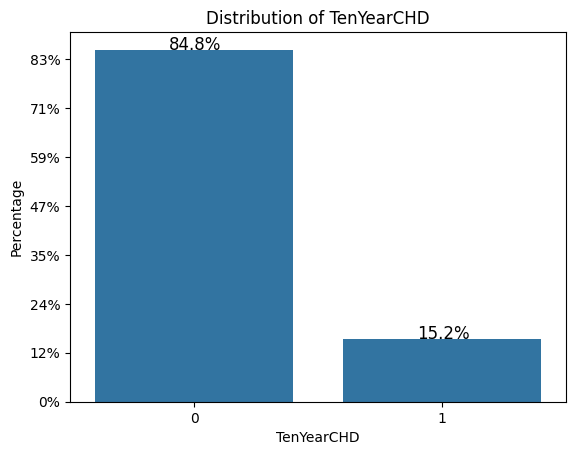

In [5]:

ax = sns.countplot(data=df, x='TenYearCHD')

for p in ax.patches:
    height = p.get_height()
    total = len(df['TenYearCHD'])
    percentage = '{:.1f}%'.format(100 * height / total)
    x = p.get_x() + p.get_width() / 2 - 0.1  # Adjust x position for label
    y = p.get_y() + p.get_height()          # Adjust y position for label
    ax.annotate(percentage, (x, y), size=12)  # Annotate with percentage label

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=total))

ax.set_title('Distribution of TenYearCHD')
ax.set_xlabel('TenYearCHD')
ax.set_ylabel('Percentage')

Podemos observar logo de início que a variável alvo, TenYearCHD, não é balanceada dentro do dataset. Esse desequilíbrio na classe alvo é uma característica importante que deve direcionar a análise e a avaliação do modelo, exigindo alguns cuidados:


1.   **Acurácia como métrica limitada**: se supuséssemos um modelo que classifica todas as amostras como negativas, já teríamos 85% de acurácia e, mesmo assim, seria um modelo inútil para identificar os casos positivos. Olhar apenas para essa métrica pode levar a conclusões enganosas.
2.  Refletir sobre o contexto do problema e avaliar qual métrica se adequa melhor as necessidades da aplicação. A escolha das classes tem impactos diferentes nesse caso.
3. Existem técnicas para minimizar o impacto de desbalanceamento de classes como a SMOTE (*Synthetic Minority Oversampling Technique*) que equilibra a distribuição de classes aumentando aleatoriamente os exemplos da classe minoritária. Ele gera novos dados de treinamento virtuais por meio de uma interpolação linear.

Vamos supor um cenário na área da saúde: Seria muito ruim para um paciente receber um diagnóstico de falso negativo, isto é, ter o risco de desenvolvimento da condição e não saber disso para tomar medidas preventivas em sua vida. Logo, é importante avaliar a capacidade preditiva de um modelo para esse problema por uma métrica de análise que consiga ponderar os casos de falso negativo, como o *recall* ou *f-score*.

Sugestões de Leitura:

- [Google ML Concepts: Classification](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall)
- [SMOTE](https://www.jair.org/index.php/jair/article/view/10302)
- [Sklearn](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)


### Distribuição de Variáveis Contínuas

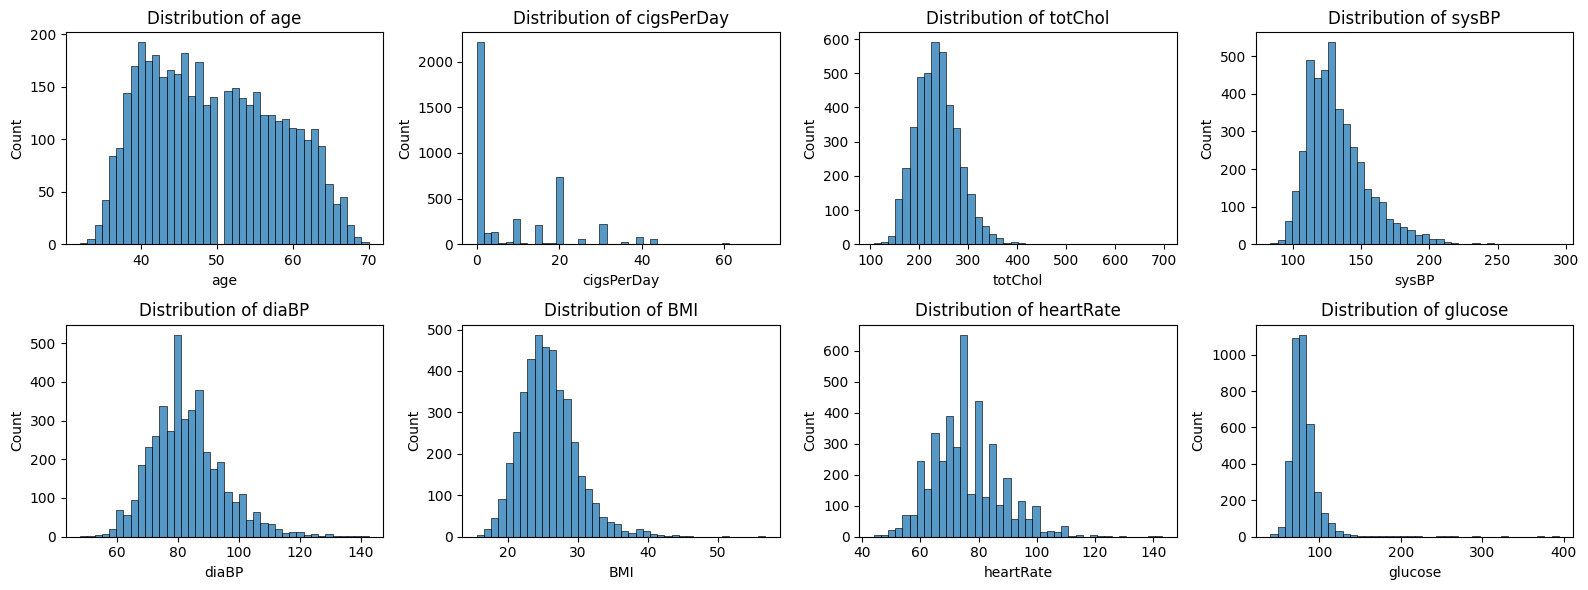

In [6]:

columns = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, bins=40, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

Podemos observar, nas distribuições das variáveis contínuas apresentadas, a presença de valores extremos em diversas delas, como em 'cigsPerDay', 'glucose' e 'totChol'. Isso indica que devemos tomar cuidado com a presença de outliers nos dados.

A maioria das distribuições apresenta assimetria, com curvas levemente deslocadas para a esquerda, sugerindo a predominância de valores concentrados em intervalos menores e algumas caudas longas para valores maiores. Por exemplo, a variável 'glucose' apresenta uma concentração acentuada em valores baixos, enquanto 'cigsPerDay' tem um grande número de observações em zero, possivelmente indicando indivíduos não fumantes.

As variáveis 'sysBP', 'diaBP' e 'BMI' se destacam por apresentarem distribuições mais próximas de uma curva normal, o que pode facilitar análises baseadas em suposições de normalidade. No entanto, mesmo nessas variáveis, é importante considerar o impacto de valores atípicos para evitar viés em modelos estatísticos ou preditivos.


### Distribuição de Variáveis Nominais

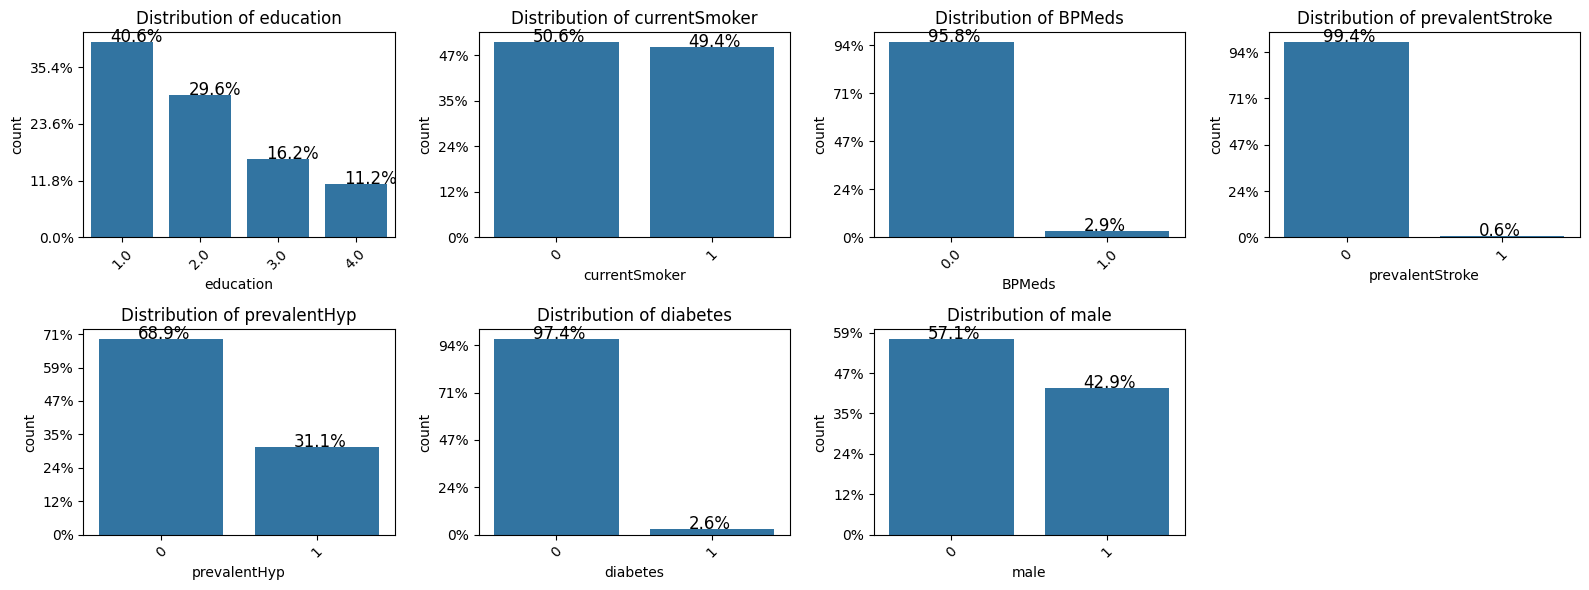

In [7]:


nominal_cols = ["education", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes", 'male']

num_plots = len(nominal_cols)
num_cols = 4
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 6))

# Flatten the axes array for easier iteration
# If there's only one plot, axes won't be an array, so we handle it separately
if num_plots == 1:
    axes = [axes]  # Wrap in a list if there's only one plot
else:
    axes = axes.flatten()

# Loop through each column and create a bar plot using Seaborn
for i, col in enumerate(nominal_cols):
    ax = sns.countplot(data=df, x=col, ax=axes[i])

    # Add percentage labels
    for p in ax.patches:
        height = p.get_height()
        total = len(df[col])
        percentage = '{:.1f}%'.format(100 * height / total)
        x = p.get_x() + p.get_width() / 2 - 0.15  # Adjust x position for label
        y = p.get_y() + p.get_height()            # Adjust y position for label
        ax.annotate(percentage, (x, y), size=12)  # Annotate with percentage label

    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=len(df[col])))  # Format y-axis as percentage

# Remove empty subplots (if any)
if num_plots < len(axes):
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

Analisando as distribuições das variáveis categóricas, podemos entender melhor o perfil da base de dados.

Por exemplo as proporções extremamente baixas para algumas categorias, como 'BPMeds', 'diabetes' e 'prevalentStroke', indicam que esses eventos são raros na amostra. Por isso, essas variáveis podem não ter um peso tão significativo na previsão de resultados, dependendo do modelo utilizado.

Outro ponto de destaque é a distribuição equilibrada entre fumantes e não fumantes, o que pode ser uma característica relevante ao analisar o impacto do tabagismo na saúde. Já as variáveis relacionadas à hipertensão ('prevalentHyp') e ao gênero ('male') mostram uma distribuição mais desigual, com prevalência de pessoas sem hipertensão (68,9%) e uma leve predominância de mulheres (57,1%) na amostra.

### Relação entre Variáveis dependentes e a independente

### Distribuição de Variáveis Contínuas por TenYearCHD

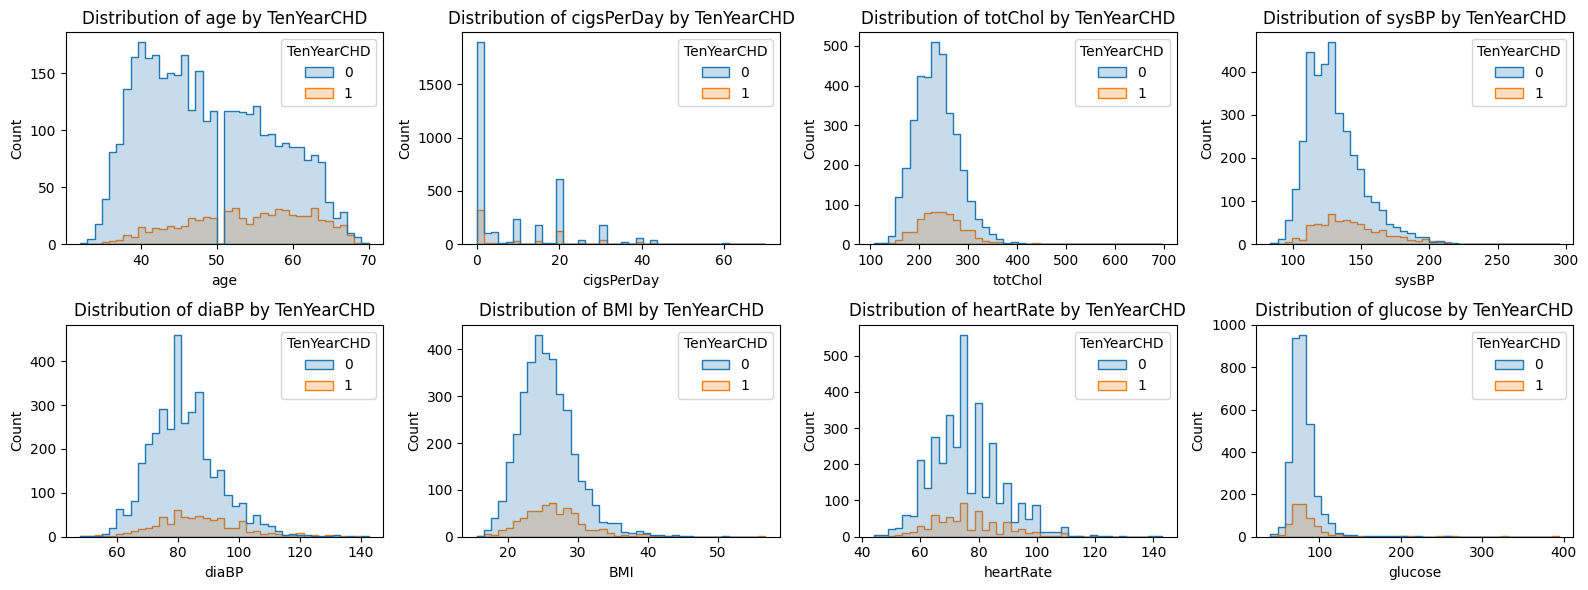

In [8]:
columns = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, bins=40, hue='TenYearCHD', element='step', ax=axes[i]) # Dividir por 'TenYearCHD'
    axes[i].set_title(f'Distribution of {col} by TenYearCHD') # Alterar o título

plt.tight_layout()
plt.show()

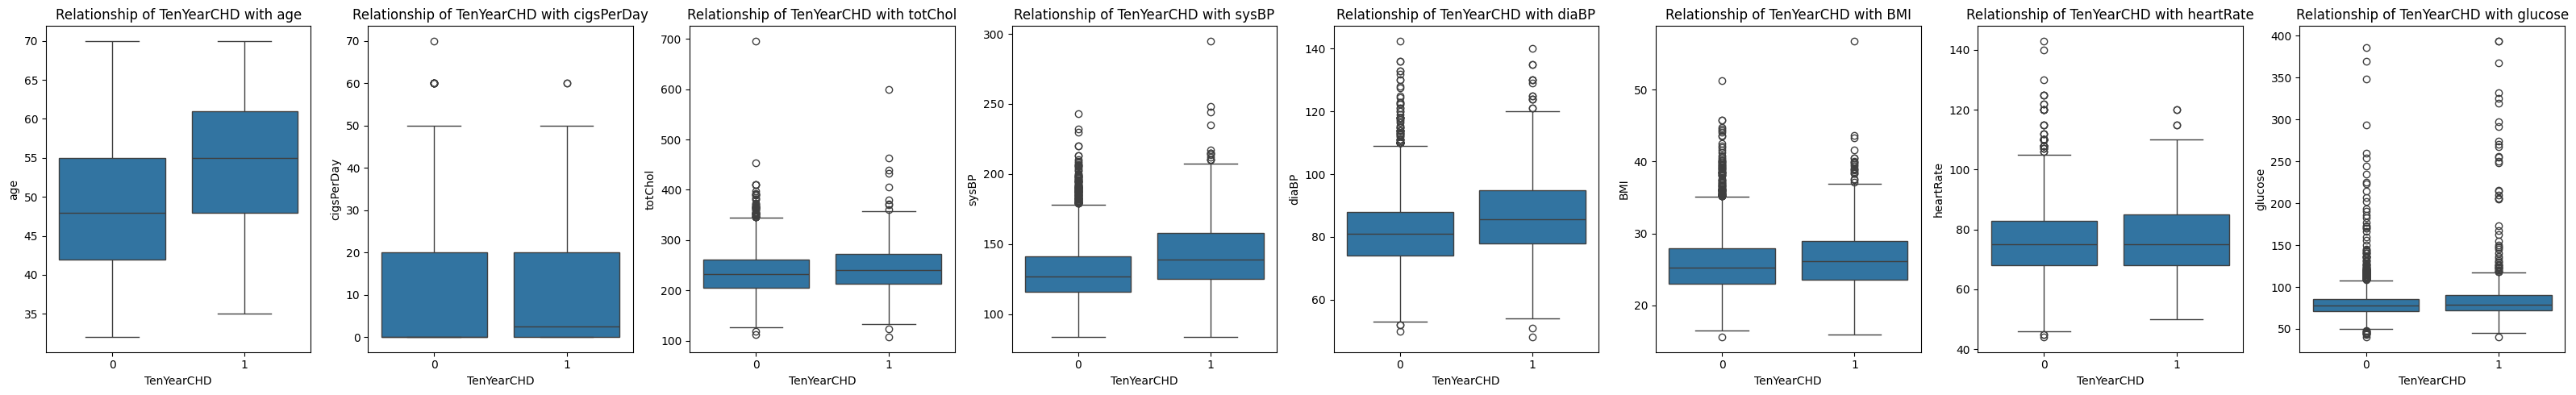

In [9]:
columns = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
fig, axes = plt.subplots(nrows=1, ncols=len(columns), figsize=(32, 5))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, col in enumerate(columns):
    sns.boxplot(x='TenYearCHD', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Relationship of TenYearCHD with {col}')

plt.tight_layout()
plt.show()

Analisando as variáveis contínuas em relação à marcação da doença, identificamos padrões de diferenciação claros, como no caso da variável 'age', onde indivíduos positivos (1) tendem a ser mais velhos. O mesmo comportamento é observado em 'sysBP', 'diaBP' e, de forma mais sutil, em 'BMI'. Isso sugere que essas variáveis têm potencial para discriminar bem os grupos, sendo candidatas promissoras como preditores.

Os boxplots revelaram ainda a presença de outliers em variáveis como 'glucose' e as de pressão arterial. Esses valores extremos podem impactar modelos e análises, sendo necessário avaliar se são representativos ou apenas ruído.

Vale destacar que as variáveis de pressão arterial ('sysBP' e 'diaBP') provavelmente estão correlacionadas, o que pode ser relevante para evitar multicolinearidade em modelos lineares. Além disso, uma análise mais profunda da distribuição de 'BMI' e testes estatísticos podem confirmar se as diferenças observadas são significativas, mesmo quando menos evidentes.

Por fim, como a idade está fortemente relacionada ao risco cardiovascular, é importante considerar ajustes para evitar que esse viés domine a análise, garantindo que outros fatores relevantes também sejam considerados

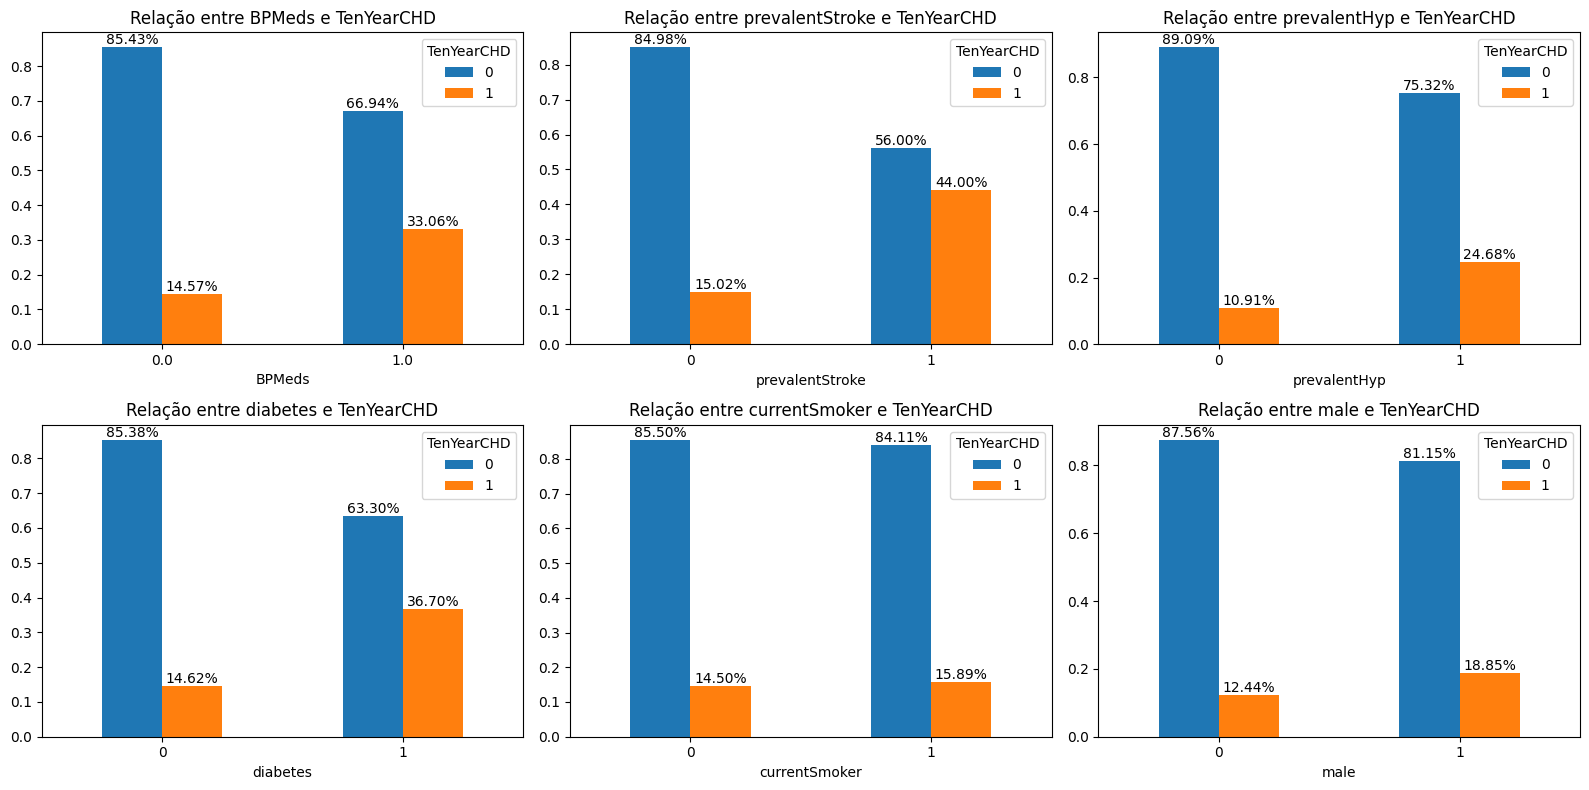

In [10]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(['BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'currentSmoker', 'male']):
    ct = pd.crosstab(df[col], df['TenYearCHD'], normalize='index')
    ax = ct.plot(kind='bar', ax=axes[i], rot=0)  # Use the current subplot
    ax.set_title(f'Relação entre {col} e TenYearCHD')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{(height*100):.2f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

A análise das variáveis categóricas revelou padrões importantes na relação com o risco de doenças cardíacas (TenYearCHD). Variáveis marcadoras como BPMeds, prevalentStroke, diabetes e prevalentHyp apresentam um aumento expressivo na proporção da classe positiva na sua presença, destacando-se como potenciais preditores.


No entanto, é importante notar que BPMeds, prevalentStroke e diabetes possuem baixa frequência no dataset (3%, 0,6% e 2,6%, respectivamente), o que pode limitar sua contribuição prática na modelagem. Já prevalentHyp, com maior representatividade, mostrou um aumento de 10,91% para 24,68% na prevalência da classe positiva, reforçando sua relevância.

Entre as variáveis mais equilibradas, destaca-se o sexo masculino (male), que apresentou um aumento de 12,44% para 18,85% na prevalência da classe positiva, indicando uma leve associação com maior risco. Por outro lado, o tabagismo atual (currentSmoker) mostrou um aumento mais sutil, sugerindo que, isoladamente, pode não ser um forte discriminador no contexto analisado.

---

Esses resultados refletem fatores de risco já conhecidos na literatura médica, isto é, a presença de condições clínicas anteriores, pode ser um fator que eleva o risco de desenvolver a condição da doença coronariana. Mas ressaltam a importância de explorar correlações e ajustar a análise para a baixa representatividade de algumas variáveis marcadoras.

### Análise da relação do risco com var education

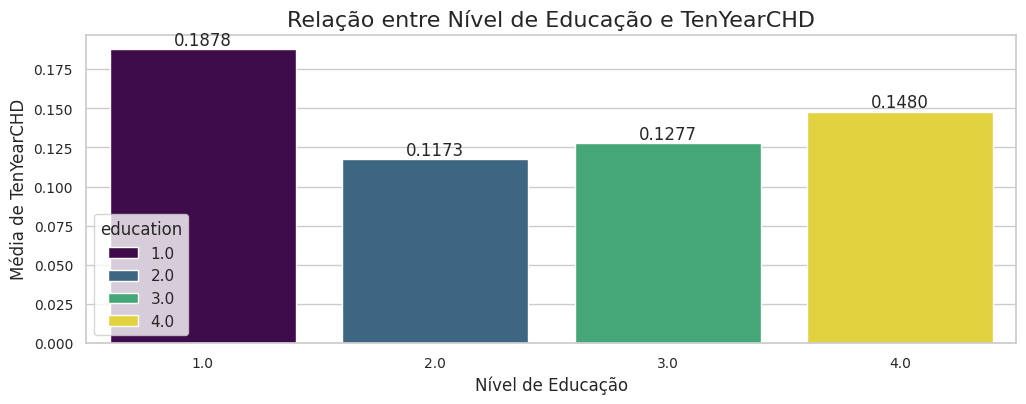

In [11]:
education_chd_means = df.groupby('education')['TenYearCHD'].mean().reset_index()

sns.set(style="whitegrid")

plt.figure(figsize=(12, 4))
ax = sns.barplot(x='education', y='TenYearCHD', hue='education', data=education_chd_means, palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', label_type='edge')

plt.title('Relação entre Nível de Educação e TenYearCHD', fontsize=16)
plt.xlabel('Nível de Educação', fontsize=12)
plt.ylabel('Média de TenYearCHD', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

Com base no gráfico, se evidencia que a relação entre o nível de educação e a média de risco de TenYearCHD não segue um padrão linear claro. Aqui estão alguns pontos importantes a considerar:

1. Maior média para education = 1:

 - O nível de educação mais baixo (1) apresenta a maior média de risco. Isso pode indicar que indivíduos com menor escolaridade estão mais expostos a fatores de risco associados à doença.
2. Aumento inconsistente entre education = 2, 3, 4:

 - Entre os níveis 2, 3 e 4, há um aumento na média de risco, mas não de forma proporcional. Isso sugere que a diferença entre os níveis pode não ser puramente ordinal (distâncias iguais entre categorias).

### Correlações

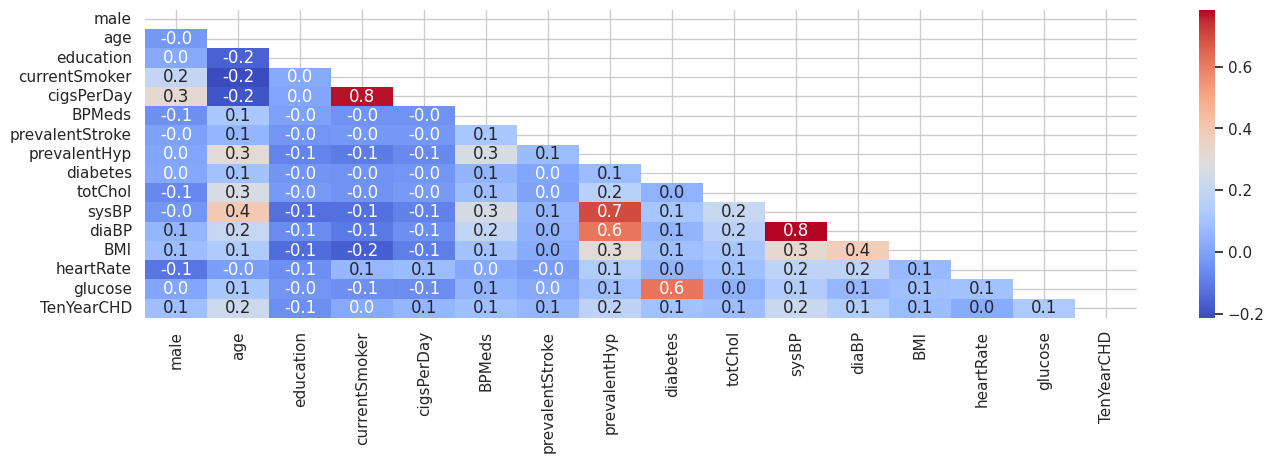

In [12]:
corr = df.corr()
plt.figure(figsize=(16, 4))

sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', mask=np.triu(corr))

plt.show()

As correlações observadas são esperadas e fazem sentido:
- (cigsPerDay, currentSmoker): Fumantes tendem a fumar mais cigarros.
- (sysBP, prevalentHyp) e (diaBP, prevalentHyp): Hipertensão preexistente reflete valores elevados de pressão arterial tanto no limiar máximo (sistólica) quanto no mínimo (diastólica).
- (glucose, diabetes): Diabetes está associado a níveis elevados de glicose no sangue.
- (diaBP, sysBP): As pressões sistólica e diastólica estão intrinsecamente relacionadas.

Para avaliar o impacto das correlações no processo de modelagem podemos analisar algumas métricas:
- Multicolinearidade: Use Variance Inflation Factor (VIF) para identificar variáveis redundantes. O VIF fornece um índice que mede o grau de aumento da variância de um coeficiente de regressão estimado devido à colinearidade.
- Avaliar teste de significância do ajuste do modelo com as variáveis e suas interações.

A multicolinearidade acontece quando duas ou mais variáveis explicativas estão fortemente correlacionadas entre si. Isso pode ser problemático porque, ao invés de cada variável trazer informações novas e únicas, elas "repetem" dados que já estão sendo capturados por outras. Como resultado, os coeficientes do modelo podem se tornar instáveis e difíceis de interpretar.

Para identificar e quantificar esse problema, utilizamos uma métrica chamada VIF (Variance Inflation Factor, ou Fator de Inflação da Variância).

### Analisando Interações

Os gráficos de interação são ferramentas visuais poderosas que nos ajudam a entender como duas variáveis independentes influenciam juntas uma variável dependente. Eles são especialmente úteis quando queremos explorar se o efeito de uma variável sobre o desfecho muda dependendo do nível de outra variável.

---

**Como ler um gráfico de interação?**

A leitura de um gráfico de interação é simples, mas exige atenção a alguns pontos-chave:
1. Observe as linhas (suas inclinações e distâncias):

  - Linhas paralelas sugerem que não há interação significativa. Ou seja, o efeito de uma variável no desfecho é o mesmo, independentemente da outra.
  - Linhas que cruzam ou têm inclinações muito diferentes indicam interação significativa. Isso sugere que o impacto de uma variável depende do estado da outra.

2. Considere os intervalos de confiança (áreas sombreadas):
  - Eles indicam a incerteza na estimativa da média. Sobreposição entre intervalos sugere que as diferenças podem não ser estatisticamente significativas.

  
[R-Project](https://cran.r-project.org/web/packages/sjPlot/vignettes/plot_interactions.html)


In [13]:
def interaction_plot(df, independent_vars, target_var, comparison_var):
    """
    Creates interaction plots to visualize the relationship between independent variables,
    a target variable, and a comparison variable.

    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        independent_vars (list): A list of independent variable names.
        target_var (str): The name of the target variable.
        comparison_var (str): The name of the comparison variable.
    """
    num_plots = len(independent_vars)
    num_cols = 4
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
    axes = axes.flatten()

    for i, var in enumerate(independent_vars):
        sns.lineplot(
            data=df,
            x=var,
            y=target_var,
            hue=comparison_var,
            marker='o',
            palette='Set1',
            ax=axes[i]
        )

        axes[i].set_title(f'{var} and {comparison_var} on {target_var}', fontsize=12)
        axes[i].set_ylabel(f'Mean of {target_var}', fontsize=10)
        axes[i].set_xlabel(var, fontsize=10)
        axes[i].legend(title=f'{comparison_var}', fontsize=8)
        axes[i].grid(True)

    if num_plots < num_rows * num_cols:
        for i in range(num_plots, num_rows * num_cols):
            fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

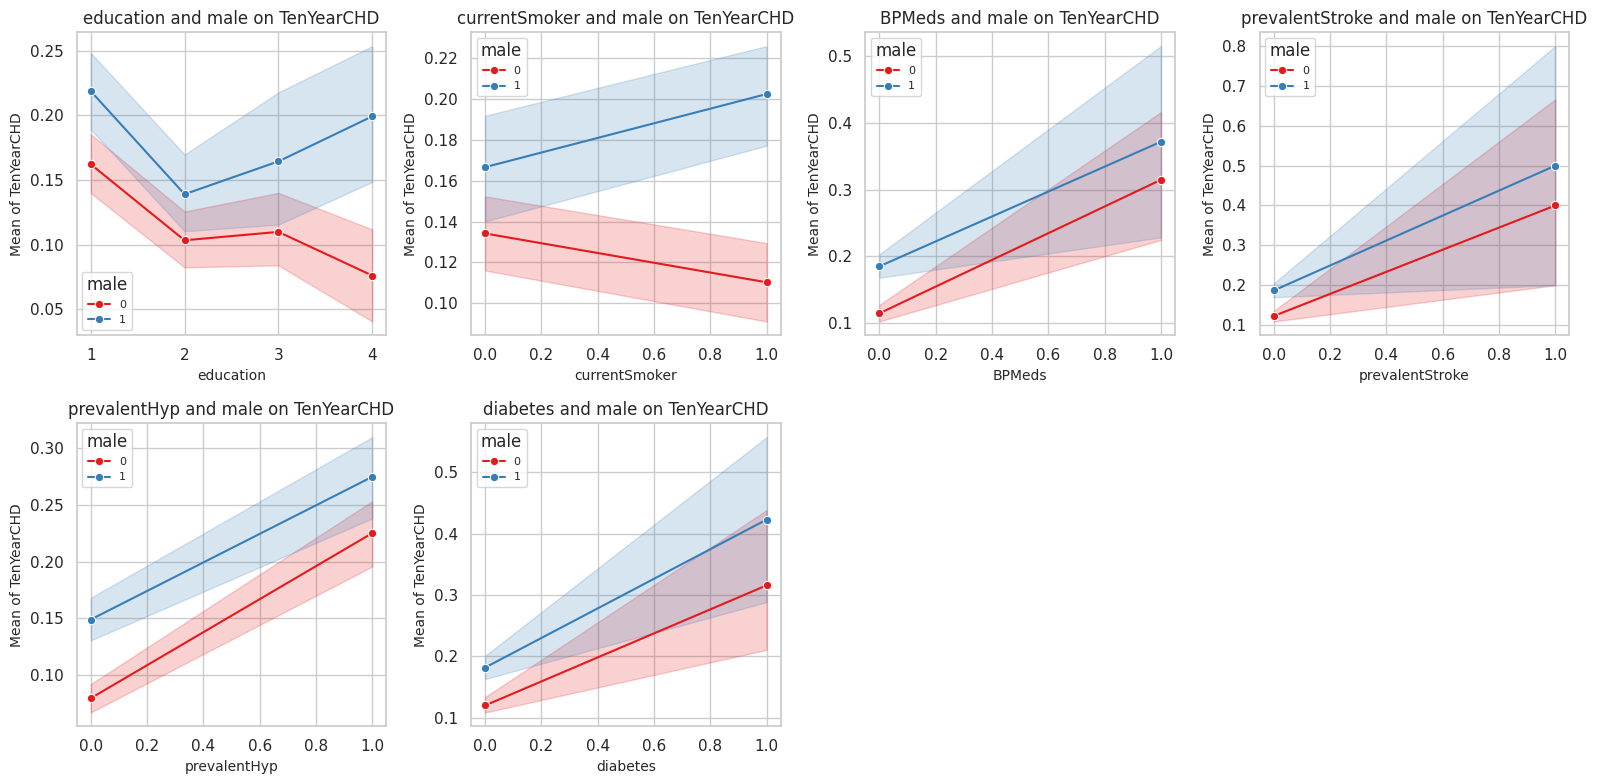

In [14]:
independent_vars = [
    'education', 'currentSmoker','BPMeds',
    'prevalentStroke', 'prevalentHyp', 'diabetes'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'male')

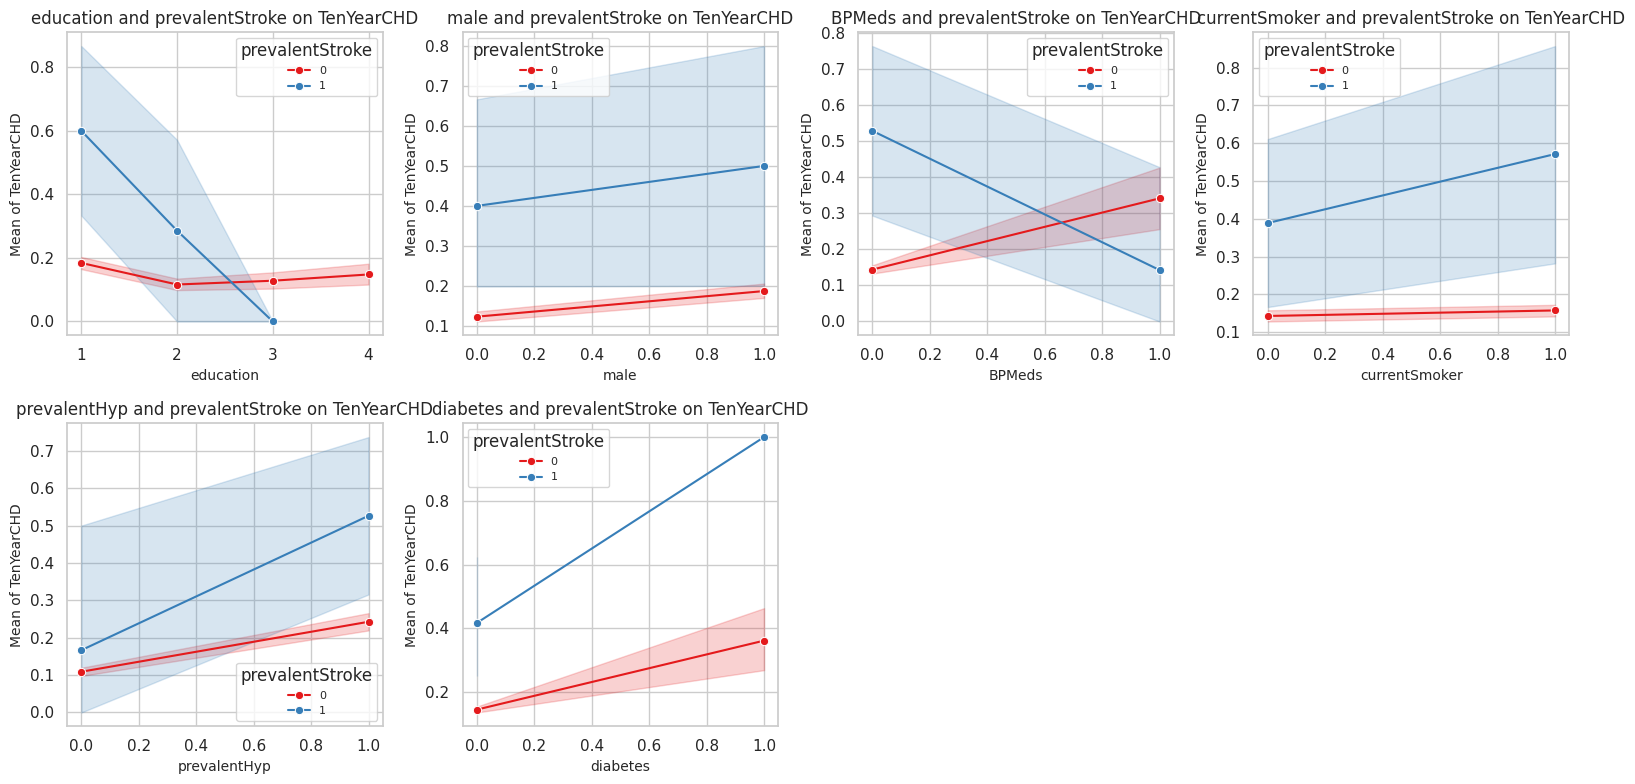

In [15]:
independent_vars = [
    'education', 'male','BPMeds', 'currentSmoker',
    'prevalentHyp', 'diabetes'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'prevalentStroke')

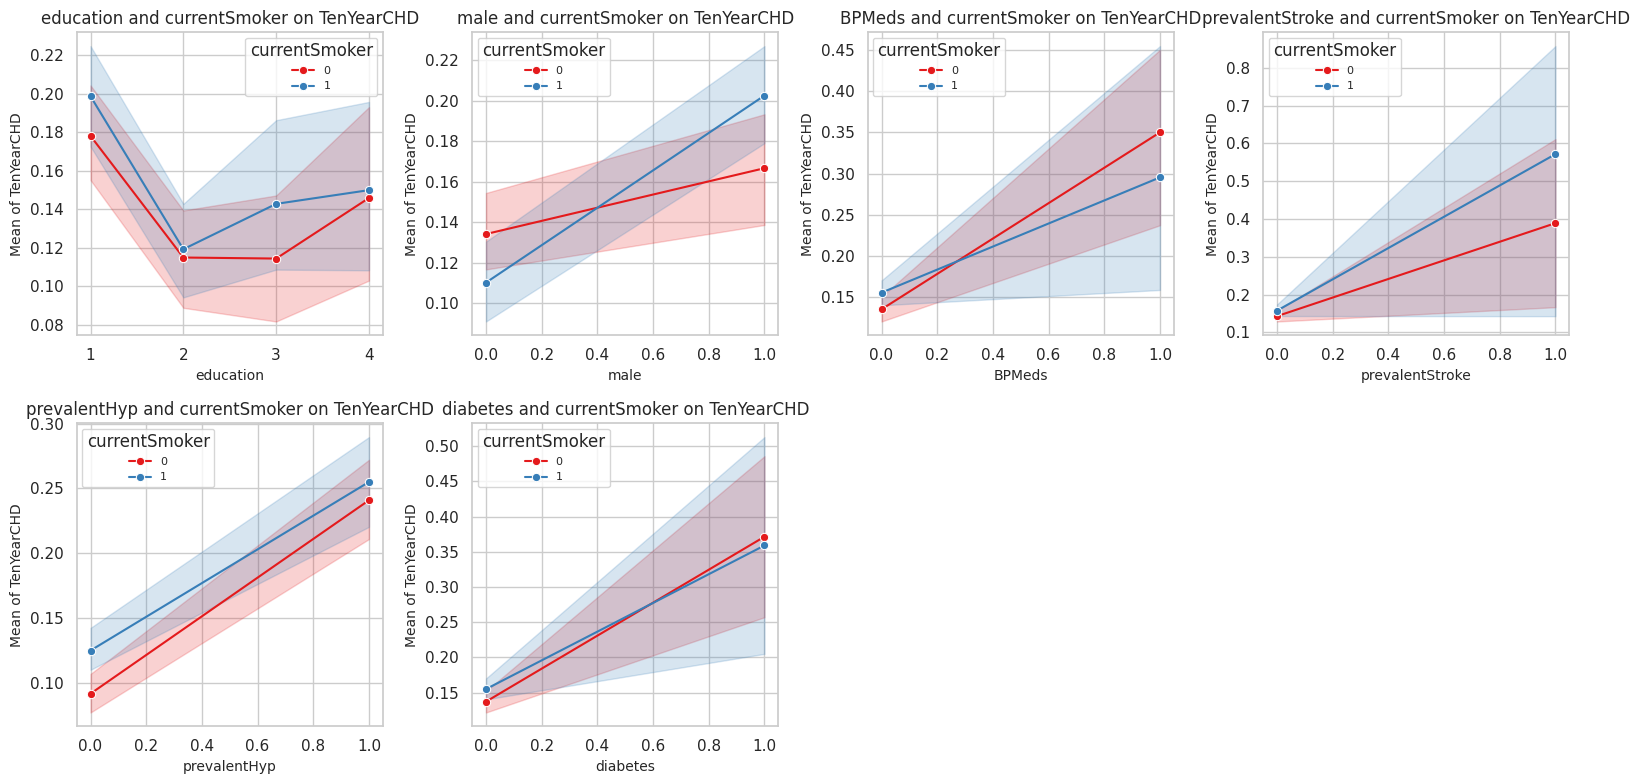

In [16]:
independent_vars = [
    'education', 'male','BPMeds',
    'prevalentStroke', 'prevalentHyp', 'diabetes'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'currentSmoker')

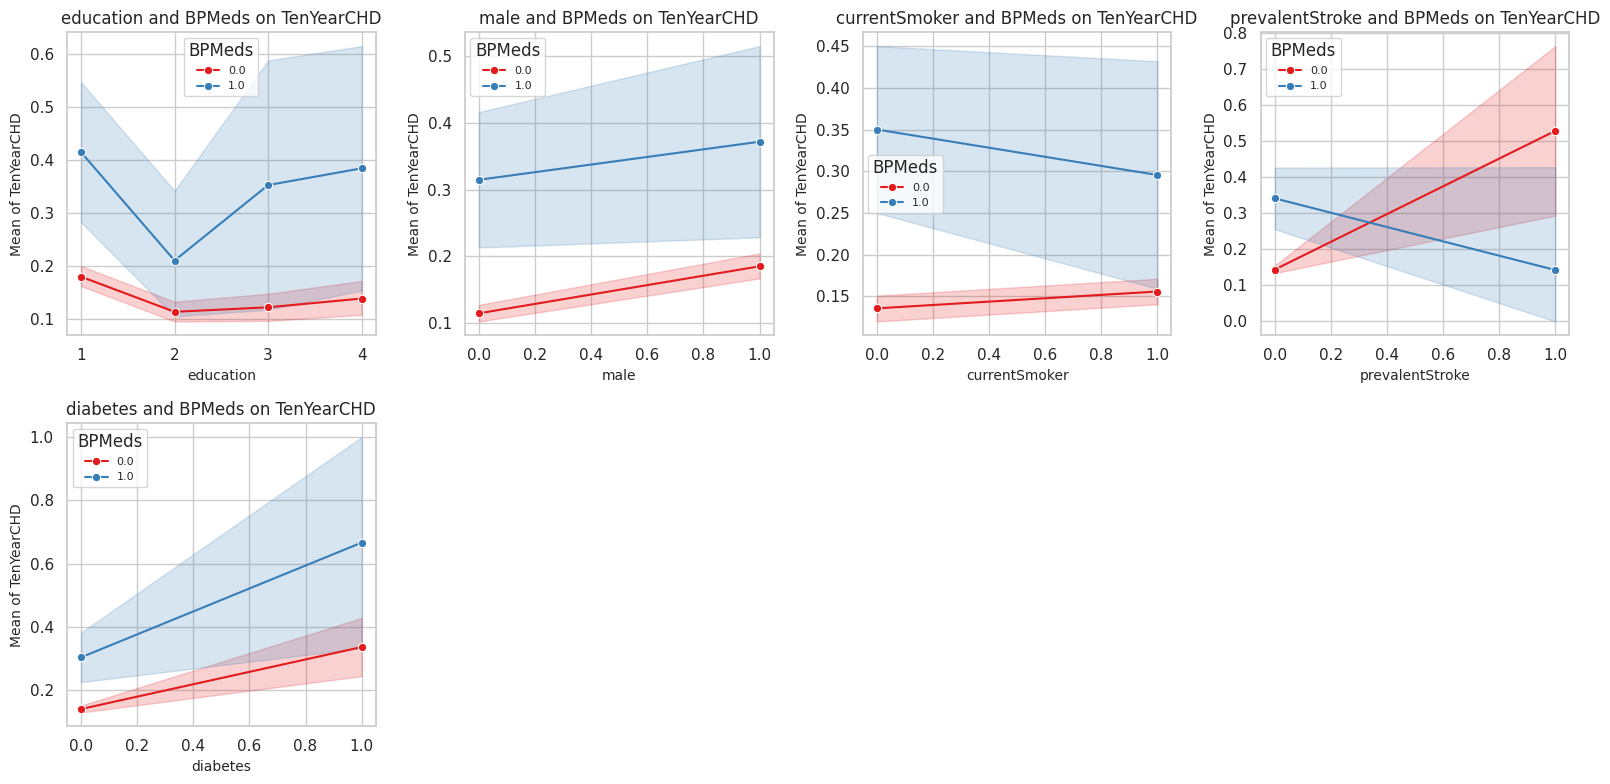

In [17]:
independent_vars = [
    'education', 'male','currentSmoker',
    'prevalentStroke', 'diabetes'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'BPMeds')

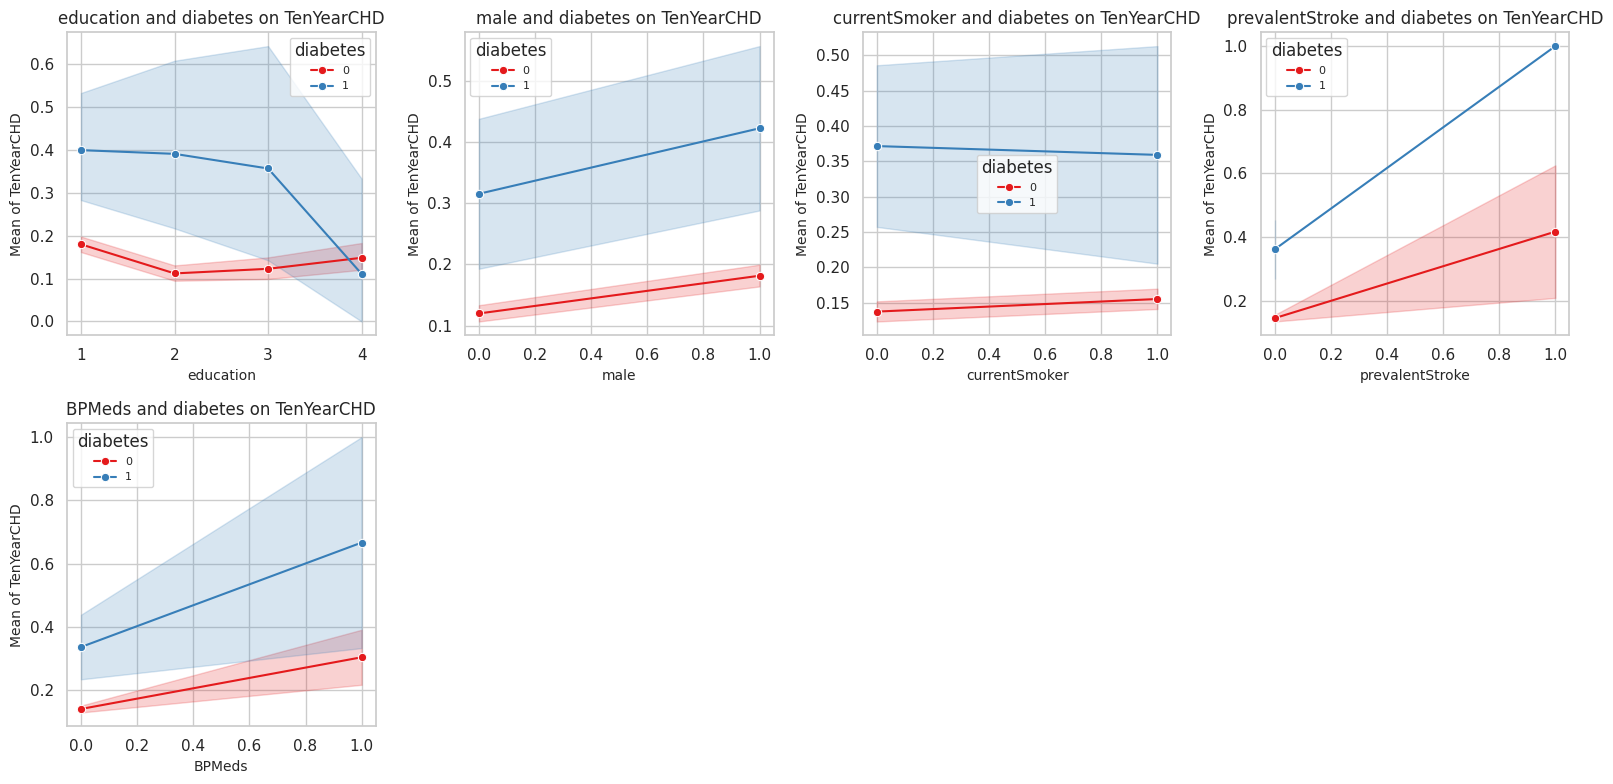

In [18]:
independent_vars = [
    'education', 'male','currentSmoker',
    'prevalentStroke',  'BPMeds'
]
interaction_plot(df, independent_vars, 'TenYearCHD', 'diabetes')

Vamos explorar alguns exemplos dos gráficos gerados:

1. Sexo (masculino) e fumar:
  
  Pode-se ver que homens (male = 1) apresentam um risco maior de *TenYearCHD* em comparação com mulheres (male = 0), mas esse efeito é amplificado para fumantes. As linhas não são paralelas, indicando interação.


2. Hipertensão e fumar:

  Tanto fumantes quanto não fumantes apresentam um aumento no risco de *TenYearCHD*  com hipertensão prevalente (prevalentHyp). No entanto, o risco é consistentemente maior para fumantes em todos os níveis de hipertensão.

3. Educação e Prevalência de AVC (Stroke):

  Em indivíduos sem AVC, o risco de *TenYearCHD*  diminui conforme o nível de educação aumenta, indicando que maior escolaridade pode estar associada a um estilo de vida mais saudável.
Para indivíduos com AVC, o risco também diminui com maior educação, mas permanece muito mais alto em comparação com aqueles sem AVC.

4. Fumar e Prevalência de AVC:

  Fumantes têm risco maior de *TenYearCHD* , mesmo sem AVC.
Em fumantes com AVC, o risco aumenta substancialmente.
Conclusão: Fumar exacerba o efeito do AVC no risco de *TenYearCHD* , reforçando a necessidade de intervenções para controle/redução de tabajismo.

5. Medicamentos para Pressão e Prevalência de AVC
  
  Sem AVC, o uso de medicamentos para pressão parece reduzir ligeiramente o risco de *TenYearCHD*.
  Com AVC, o uso de medicamentos para pressão não diminui o risco de *TenYearCHD* significativamente, o que pode sugerir que o AVC sobrepõe os benefícios dos medicamentos.
Conclusão: A interação aqui reflete como a prevalência de AVC pode neutralizar parcialmente o efeito positivo de tratamentos de pressão.


### Analisando Linearidade dos Dados


Interpretação: Se a probabilidade de DAC não cresce de forma constante nos bins de valores, pode ser um indício de não-linearidade.

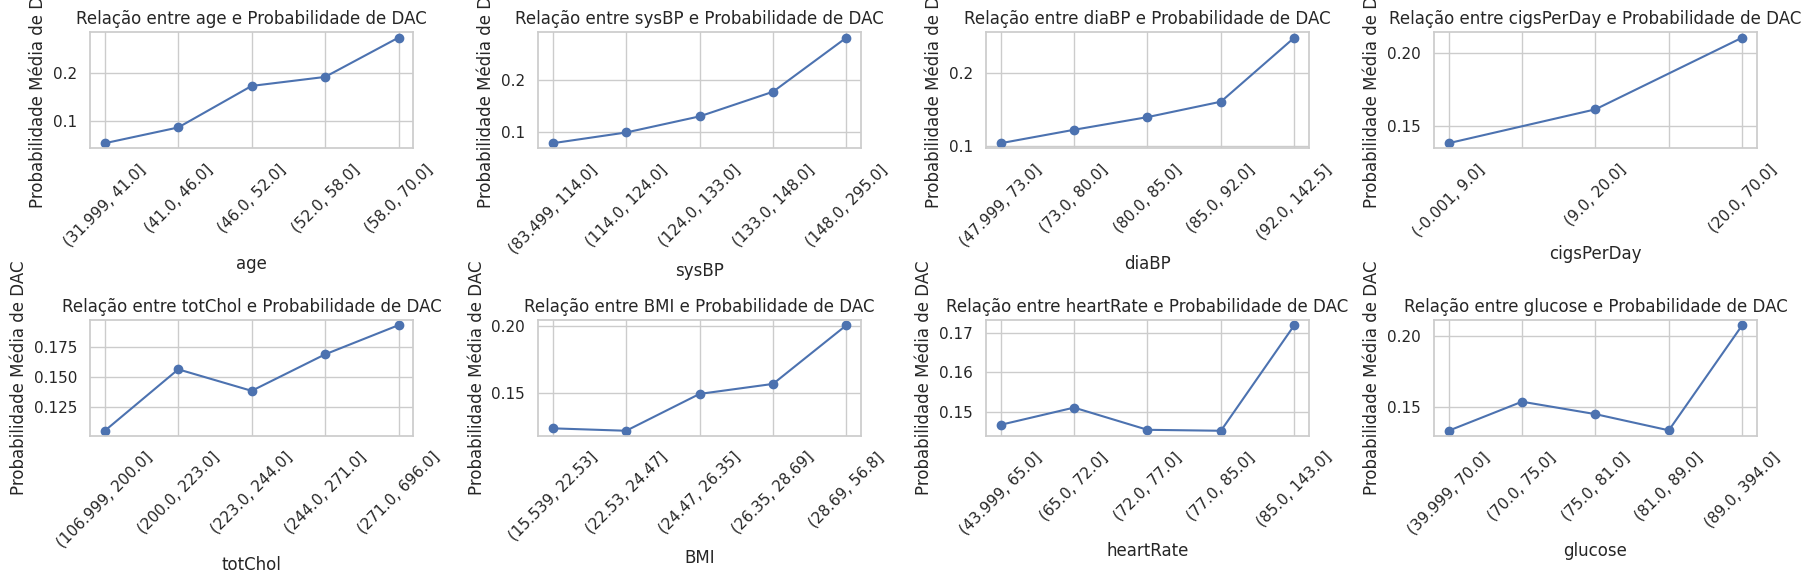

In [19]:
vars_continuas = ['age', 'sysBP', 'diaBP', 'cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']

num_bins = 5
df_bins = df.copy()

num_rows = 2
num_cols = 4

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(18,6))


for i, var in enumerate(vars_continuas):
    row = i // num_cols
    col = i % num_cols

    df_bins[f"{var}_bin"] = pd.qcut(df_bins[var], q=num_bins, duplicates="drop")
    bin_means = df_bins.groupby(f"{var}_bin", observed=True)["TenYearCHD"].mean()

    ax = axes[row, col]
    bin_means.plot(marker="o", linestyle="-", color="b", ax=ax)

    ax.set_xlabel(var)
    ax.set_ylabel("Probabilidade Média de DAC")
    ax.set_title(f"Relação entre {var} e Probabilidade de DAC")
    ax.tick_params(axis='x', rotation=45)  # Rotate x-axis labels
    ax.grid(True)

plt.tight_layout()
plt.show()


Queremos observar se há ganhos em adicionar o termos quadráticos


[LOESS plot](https://en.wikipedia.org/wiki/Local_regression)

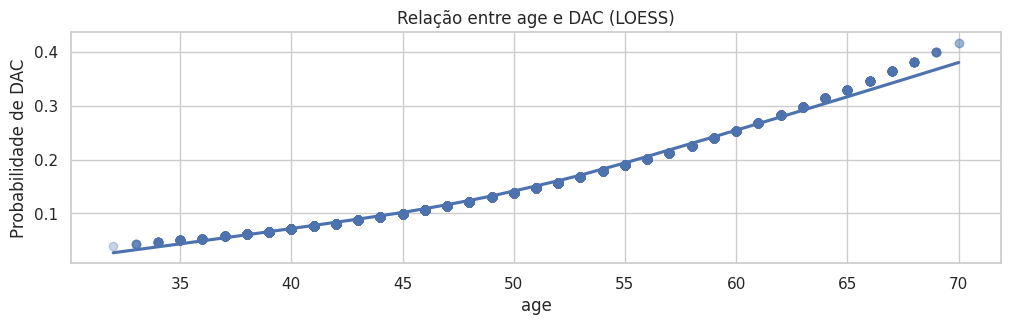

Variável: age
Estatística do Teste: 5.0464, p-valor: 0.0247



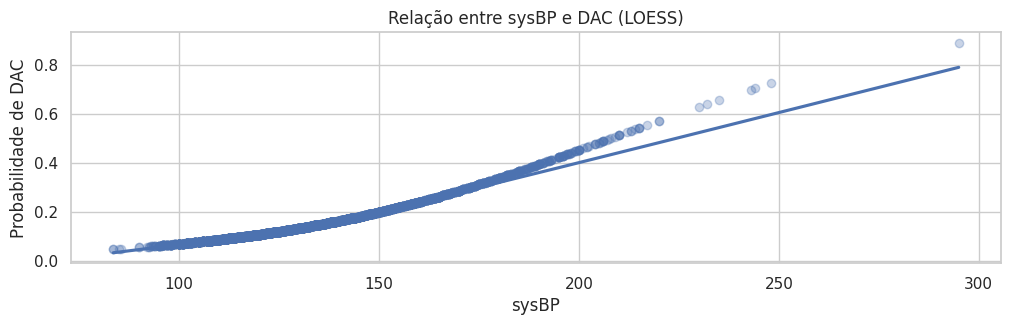

Variável: sysBP
Estatística do Teste: 0.5124, p-valor: 0.4741



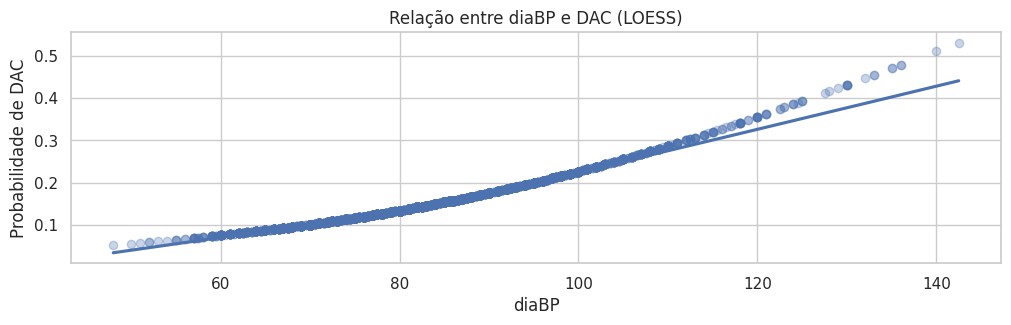

Variável: diaBP
Estatística do Teste: 4.9163, p-valor: 0.0266



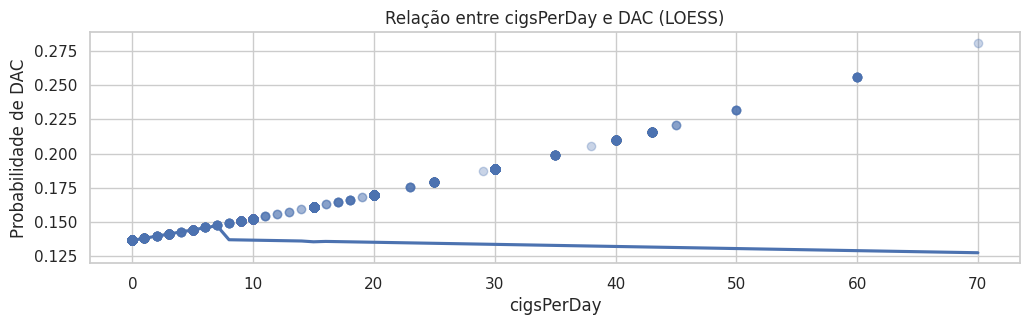

Variável: cigsPerDay
Estatística do Teste: 0.2637, p-valor: 0.6076



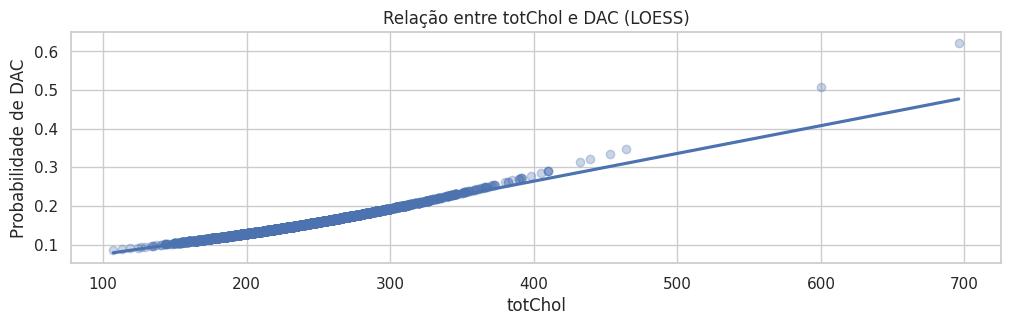

Variável: totChol
Estatística do Teste: 0.1665, p-valor: 0.6833



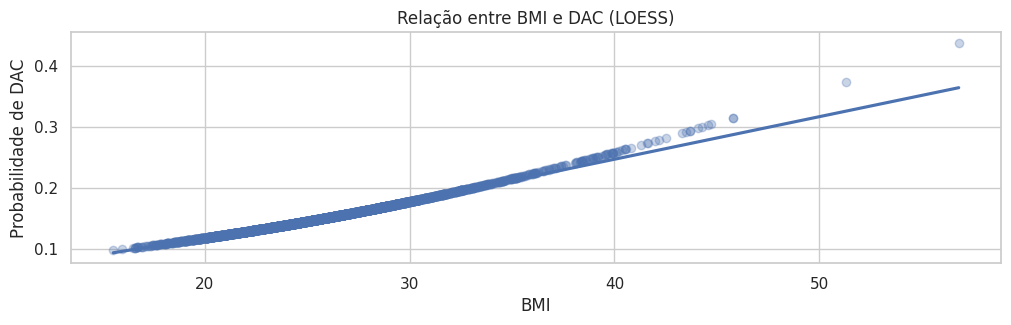

Variável: BMI
Estatística do Teste: 0.1432, p-valor: 0.7051



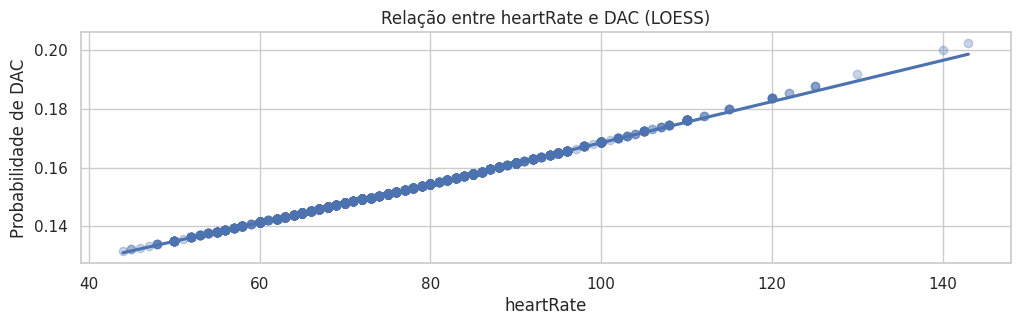

Variável: heartRate
Estatística do Teste: 0.0069, p-valor: 0.9339



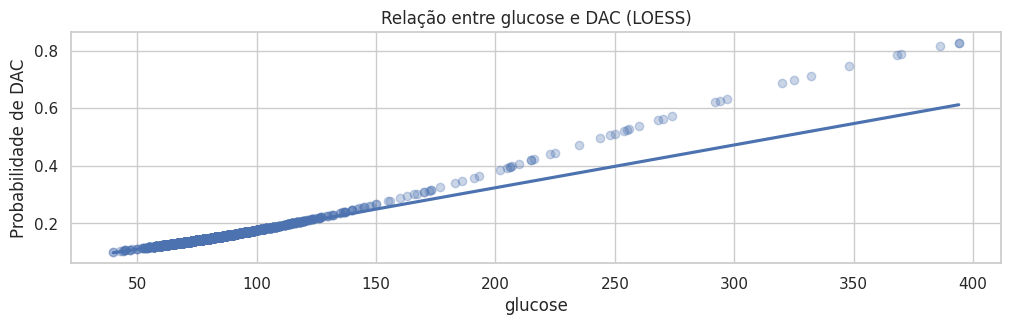

Variável: glucose
Estatística do Teste: 0.0403, p-valor: 0.8409



In [20]:
vars_to_analyze = ['age',  'sysBP', 'diaBP', 'cigsPerDay', 'totChol','BMI', 'heartRate', 'glucose' ]
df_copy = df.copy()

for var in vars_to_analyze:
    df_copy[var] = df_copy[var].replace([np.inf, -np.inf], np.nan)
    df_copy[var] = df_copy[var].fillna(df_copy[var].median())

    df_copy["prob_CHD"] = sm.Logit(df_copy["TenYearCHD"], sm.add_constant(df_copy[var])).fit(disp=0).predict()

    plt.figure(figsize=(12, 3))
    sns.regplot(x=var, y="prob_CHD", data=df_copy, lowess=True, scatter_kws={'alpha':0.3})
    plt.xlabel(var)
    plt.ylabel("Probabilidade de DAC")
    plt.title(f"Relação entre {var} e DAC (LOESS)")
    plt.show()

    linear_model = smf.logit(f"TenYearCHD ~ {var}", data=df_copy).fit(disp=0)

    squared_model = smf.logit(f"TenYearCHD ~ {var} + I({var}**2)", data=df_copy).fit(disp=0)


    lr_stat = 2 * (squared_model.llf - linear_model.llf)
    p_value = chi2.sf(lr_stat, df=1)

    print(f"Variável: {var}")
    print(f"Estatística do Teste: {lr_stat:.4f}, p-valor: {p_value:.4f}\n")

## Tratamento dos dados

### Valores ausentes

In [21]:

total_null_percentage = df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100
print(f"Total percentage of null values: {total_null_percentage:.2f}%")


Total percentage of null values: 0.95%


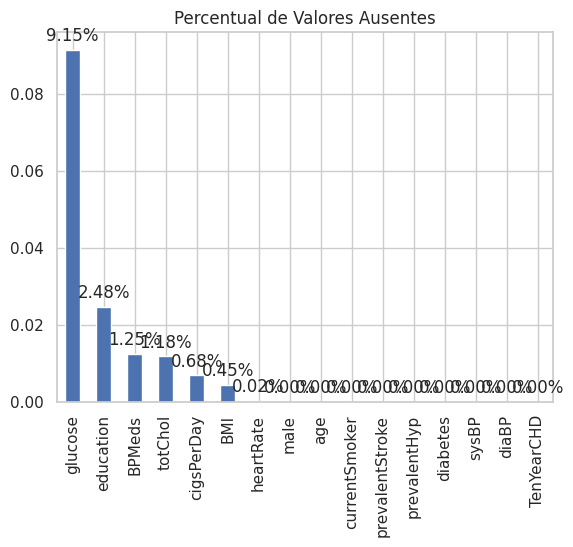

In [22]:
ax = df.isnull().mean().sort_values(ascending=False).plot(kind='bar', title='Percentual de Valores Ausentes')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

### Tratamento de Valores Ausentes


---

- Contínuos: Mediana - menos sensível a outliers.
- Categóricos: Moda.

In [23]:

def fill_missing_values(df, continuous_vars, categorical_vars):
  for col in continuous_vars:
    # df.loc[:, col] = df[col].fillna(df[col].mean())
    df.loc[:, col] = df[col].fillna(df[col].median())

  for col in categorical_vars:
    df.loc[:, col] = df[col].fillna(df[col].mode()[0])
  return df

In [24]:
continuous_vars = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
categorical_vars = ['education', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'currentSmoker', 'male']

df = fill_missing_values(df, continuous_vars, categorical_vars)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4240 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4240 non-null   float64
 5   BPMeds           4240 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4240 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4240 non-null   float64
 13  heartRate        4240 non-null   float64
 14  glucose          4240 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [25]:
total_null_percentage = df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100
print(f"Total percentage of null values: {total_null_percentage:.2f}%")

Total percentage of null values: 0.00%




### Transformção de Variaveis categóricas em dummies
---
- Transforma a variável *education* em dummies variables pois a relação não é exatamente linear.


In [26]:

def create_dummies(df, categorical_vars_with_dummies):
    df = pd.get_dummies(df, columns=categorical_vars_with_dummies, drop_first=True,dtype='int')
    return df

In [27]:
df = create_dummies(df, categorical_vars_with_dummies=['education'])

df = df.rename(columns={
    'education_2.0': 'education_2',
    'education_3.0': 'education_3',
    'education_4.0': 'education_4'
})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   currentSmoker    4240 non-null   int64  
 3   cigsPerDay       4240 non-null   float64
 4   BPMeds           4240 non-null   float64
 5   prevalentStroke  4240 non-null   int64  
 6   prevalentHyp     4240 non-null   int64  
 7   diabetes         4240 non-null   int64  
 8   totChol          4240 non-null   float64
 9   sysBP            4240 non-null   float64
 10  diaBP            4240 non-null   float64
 11  BMI              4240 non-null   float64
 12  heartRate        4240 non-null   float64
 13  glucose          4240 non-null   float64
 14  TenYearCHD       4240 non-null   int64  
 15  education_2      4240 non-null   int64  
 16  education_3      4240 non-null   int64  
 17  education_4   

# 3.Modelagem

## Construção do Modelo Inicial - Irrestrito

Modelo a princípio com todas as variáveis para servir de referência na avaliação de ganhos com transformações e ajustes

In [28]:
formula = """
TenYearCHD ~male + age + education_2 +education_3 +education_4 + currentSmoker + cigsPerDay + BPMeds +
       prevalentStroke + prevalentHyp + diabetes + totChol + sysBP +
       diaBP + BMI + heartRate + glucose
"""
# 1. Dividir em treino e teste
y, X = patsy.dmatrices(formula, data=df, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 2. Ajustar o modelo
model = sm.Logit(y_train, X_train).fit()
print(model.summary())

print("\nComparação de desempenho:")
print(f"Modelo - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

# 3. Prever no conjunto de teste
y_pred_prob_test  = model.predict(X_test)

# 4. Encontrar limiar ótimo para o threshold via curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")

# 5. Classificar com limiar ótimo
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")

# 6. Métricas no teste
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Optimization terminated successfully.
         Current function value: 0.371869
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2950
Method:                           MLE   Df Model:                           17
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1272
Time:                        00:51:08   Log-Likelihood:                -1103.7
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 3.476e-58
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -8.7619      0.798    -10.986      0.000     -10.325      -7.199
male          

### Aplicando ponderação de classes
---
A ponderação de classes atribui um peso maior à classe minoritária durante o treinamento do modelo, fazendo com que o algoritmo "dê mais atenção" aos casos positivos (TenYearCHD = 1). Isso ajuda a equilibrar o viés do modelo em favor da classe majoritária.


1. Calcular os Pesos para Cada Classe:

* O peso de cada classe é inversamente proporcional à sua frequência. Por exemplo:

  * Peso da classe minoritária (1): $$\frac{\text{Total de observações}}{2\times \text{Contagem da classe 1}}$$
  * Peso da classe majoritária (0): $$\frac{\text{Total de observações}}{2\times \text{Contagem da classe 0}}$$

2. Atribuir os Pesos a Cada Observação:

* Cada observação recebe um peso correspondente à sua classe.

3. Ajustar o Modelo com `freq_weights`:

In [29]:
from sklearn.utils.class_weight import compute_class_weight

y_train_raveld = y_train.values.ravel()
# Calcular pesos das classes
classes = np.unique(y_train_raveld)
pesos = compute_class_weight('balanced', classes=classes, y=y_train_raveld )
pesos_observacoes = np.where(y_train_raveld == 1, pesos[1], pesos[0])


In [30]:
pesos

array([0.58959078, 3.29046563])

In [31]:
pesos_observacoes

array([0.58959078, 0.58959078, 0.58959078, ..., 0.58959078, 0.58959078,
       0.58959078])

In [32]:
# Usar GLM com família binomial e freq_weights
SET_USE_BIC_LLF(True)  # Usar a fórmula nova

modelo_ponderado = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Binomial(),
    freq_weights=pesos_observacoes
).fit()

print(modelo_ponderado.summary())


print("\nComparação de desempenho:")
print(f"Modelo - AIC: {modelo_ponderado.aic:.2f}, BIC: {modelo_ponderado.bic:.2f}")

y_pred_prob_test  = modelo_ponderado.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

                 Generalized Linear Model Regression Results                  
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                            GLM   Df Residuals:                     2950
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1760.0
Date:                Tue, 18 Feb 2025   Deviance:                       3519.9
Time:                        00:51:08   Pearson chi2:                 2.96e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1815
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -7.0850      0.591    -

Conclusão: O modelo prioriza recall em detrimento da precisão, o que é típico em dados desbalanceados. A ponderação não trouxe ganhos significativos, sugerindo que outros ajustes (ex.: seleção de variáveis, tratamento de outliers) são necessários.

Variance inflation factor, VIF

---
O fator de inflação da variância é uma medida do aumento da variância das estimativas de parâmetros se uma variável adicional, dada por exog_idx, for adicionada à regressão linear. É uma medida de multicolinearidade da matriz de design, exog.

Uma recomendação é que, se o VIF for maior que 5, então a variável explicativa dada por exog_idx é altamente colinear com as outras variáveis explicativas, e as estimativas de parâmetros terão grandes erros padrão por causa disso.

**Interpretation**


> The square root of the variance inflation factor indicates how much larger the standard error increases compared to if that variable had 0 correlation to other predictor variables in the model.Example: If the variance inflation factor of a predictor variable were 5.27 (√5.27 = 2.3), this means that the standard error for the coefficient of that predictor variable is 2.3 times larger than if that predictor variable had 0 correlation with the other predictor variables.

[Wikipedia - Variance inflation factor](https://en.wikipedia.org/wiki/Variance_inflation_factor#Interpretation)

In [33]:
vif_data = pd.DataFrame()
X_data = X.drop('Intercept', axis=1)
vif_data["feature"] = X_data.columns
vif_data["VIF"] = [variance_inflation_factor(X_data.values, i) for i in range(X_data.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

        feature        VIF
          sysBP 137.812213
          diaBP 135.098270
            BMI  45.205558
            age  41.623061
      heartRate  38.952293
        totChol  31.467693
        glucose  20.865930
  currentSmoker   4.740307
     cigsPerDay   4.023892
   prevalentHyp   2.376361
           male   2.118775
    education_2   1.738543
       diabetes   1.568842
    education_3   1.399127
    education_4   1.276044
         BPMeds   1.131393
prevalentStroke   1.025100


* **sysBP e diaBP**: Como são altamente correlacionadas, pode ser interessante manter apenas uma delas ou usar uma combinação (ex: média ou diferença).
* **BMI, age, heartRate, totChol, glucose**: Avaliar se alguma dessas variáveis pode ser removida sem prejudicar o modelo, pois todas possuem alta colinearidade.
* **currentSmoker e cigsPerDay**: Redundância da informação, cigsPerDay já traz se o indivíduo é fumante ou não e além de adicionar um dado de intensidade sobre o hábito.

## Modelo Cru somente com variáveis significativas

Cru - Sem transformações sobre os dados

In [34]:
def backward_selection(data, target, significance_level=0.05):
    """
    Realiza backward selection para selecionar variáveis significativas.

    Args:
        data (DataFrame): Conjunto de dados com as variáveis independentes.
        target (Series): Variável dependente.
        significance_level (float): Nível de significância para remoção de variáveis.

    Returns:
        modelo_final (OLSResults): Modelo ajustado com as variáveis selecionadas.
        variaveis_selecionadas (list): Lista das variáveis finais selecionadas.
    """
    variables = list(data.columns)
    while len(variables) > 0:
        X = data[variables]
        model = sm.Logit(target, X).fit(disp=0)
        p_values = model.pvalues[1:]
        max_p_value = p_values.max()


        if max_p_value > significance_level:
            excluded_variable = p_values.idxmax()
            variables.remove(excluded_variable)
        else:
            break


    X_final = data[variables]
    modelo_final = sm.Logit(target, X_final).fit(disp=0)

    return modelo_final, variables

In [35]:
formula = """
TenYearCHD ~ male + age + education_2 +education_3 +education_4 + currentSmoker + cigsPerDay + BPMeds +
       prevalentStroke + prevalentHyp + diabetes + totChol + sysBP +
       diaBP + BMI + heartRate + glucose
"""
y, X = patsy.dmatrices(formula, data=df, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variáveis selecionadas pelo método backward selection:")
print(selected_features)

print("\nResumo do modelo após backward selection:")
print(model.summary())

print("\nComparação de desempenho:")
print(f"Modelo backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variáveis selecionadas pelo método backward selection:
['Intercept', 'male', 'age', 'education_2', 'cigsPerDay', 'prevalentStroke', 'totChol', 'sysBP', 'glucose']

Resumo do modelo após backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2959
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1246
Time:                        00:51:09   Log-Likelihood:                -1107.0
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 2.412e-63
                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

## Modelo cru com as possíveis Interações entre Variáveis

In [36]:
formula = """
TenYearCHD ~ male + age + currentSmoker + cigsPerDay + BPMeds + education_2 +education_3 +education_4 +
prevalentStroke + prevalentHyp + diabetes + totChol + sysBP + diaBP + BMI +
heartRate +
male:currentSmoker + BPMeds:prevalentStroke + prevalentHyp:currentSmoker + prevalentStroke:currentSmoker + prevalentHyp:prevalentStroke
"""
y, X = patsy.dmatrices(formula, data=df, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variáveis selecionadas pelo método backward selection:")
print(selected_features)
print("\nResumo do modelo após backward selection:")
print(model.summary())
print("\nComparação de desempenho:")
print(f"Modelo backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))
auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variáveis selecionadas pelo método backward selection:
['Intercept', 'male', 'age', 'cigsPerDay', 'education_2', 'diabetes', 'totChol', 'sysBP', 'prevalentHyp:prevalentStroke']

Resumo do modelo após backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2959
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1214
Time:                        00:51:09   Log-Likelihood:                -1111.0
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 1.241e-61
                                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

Sem ganho aparente com a adição das interações entre as variáveis em termos do ajuste do modelo (AIC /BIC) ou em relação à capacidade preditiva

## Modelo com variáveis padronizadas

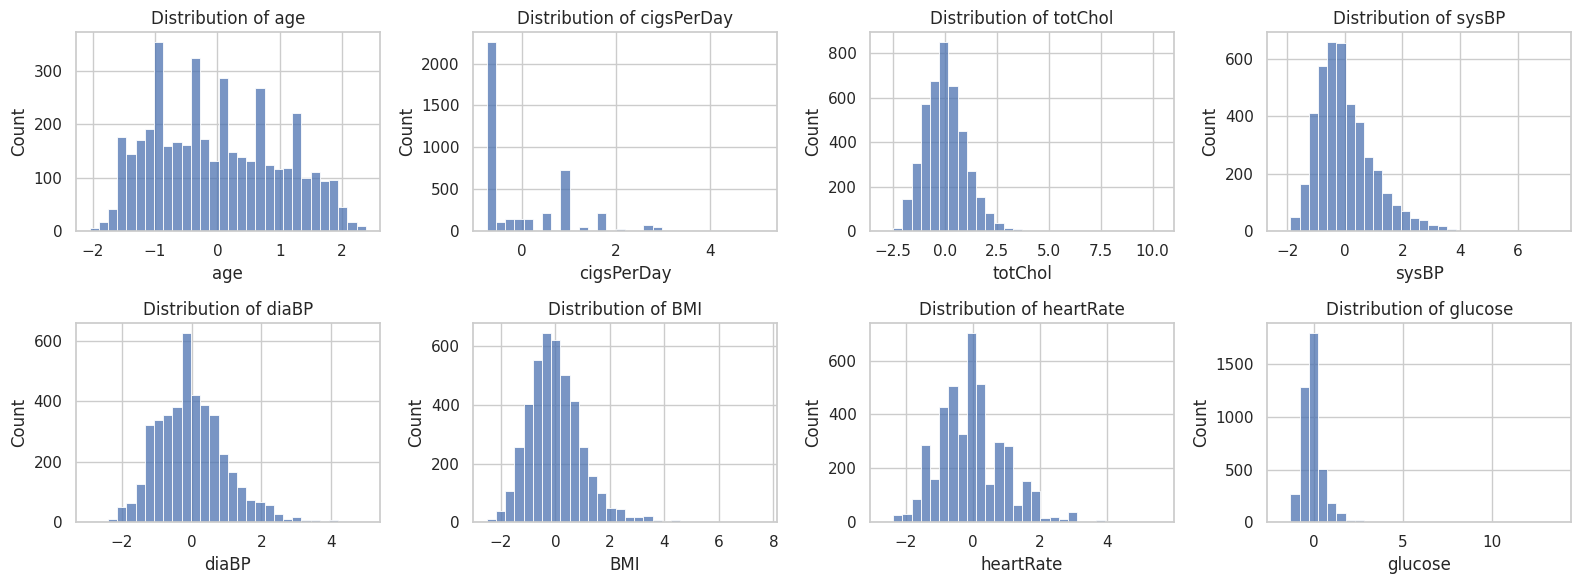

In [37]:
continuous_vars = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = StandardScaler()

df_std = df.copy()
df_std[continuous_vars] = scaler.fit_transform(df_std[continuous_vars])

columns = continuous_vars
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(columns):
    sns.histplot(data=df_std, x=col, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [38]:
formula = """
TenYearCHD ~ male + age + currentSmoker + cigsPerDay + BPMeds + education_2 +education_3 +education_4 +
prevalentStroke + prevalentHyp + diabetes + totChol + sysBP + diaBP +  BMI +
heartRate +
male:currentSmoker + BPMeds:prevalentStroke + prevalentHyp:currentSmoker + prevalentStroke:currentSmoker + prevalentHyp:prevalentStroke
"""

y, X = patsy.dmatrices(formula, data=df_std, return_type='dataframe')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variáveis selecionadas pelo método backward selection:")
print(selected_features)
print("\nResumo do modelo após backward selection:")
print(model.summary())
print("\nComparação de desempenho:")
print(f"Modelo backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))
auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variáveis selecionadas pelo método backward selection:
['Intercept', 'male', 'age', 'cigsPerDay', 'education_2', 'diabetes', 'totChol', 'sysBP', 'prevalentHyp:prevalentStroke']

Resumo do modelo após backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2959
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1214
Time:                        00:51:11   Log-Likelihood:                -1111.0
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 1.241e-61
                                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

A transformação de padronização teve como efeito apenas alterar os coeficientes das variáveis transformadas, que ficaram mais equilibrados entre sí. Porém sem impacto sobre as métricas de ajuste AIC/BIC ou as de capacidade preditiva. Logo não há ganho concreto da transformação, além de um prejuízo na interpretabilidade por conta da mudança de escalas.

## Modelo com Transformação Box-Cox

Lambdas de transformação Box-Cox:
age: 0.0635
totChol: -0.0129
sysBP: -1.2938
diaBP: -0.3859
BMI: -0.5741
heartRate: -0.2463
glucose: -1.3981


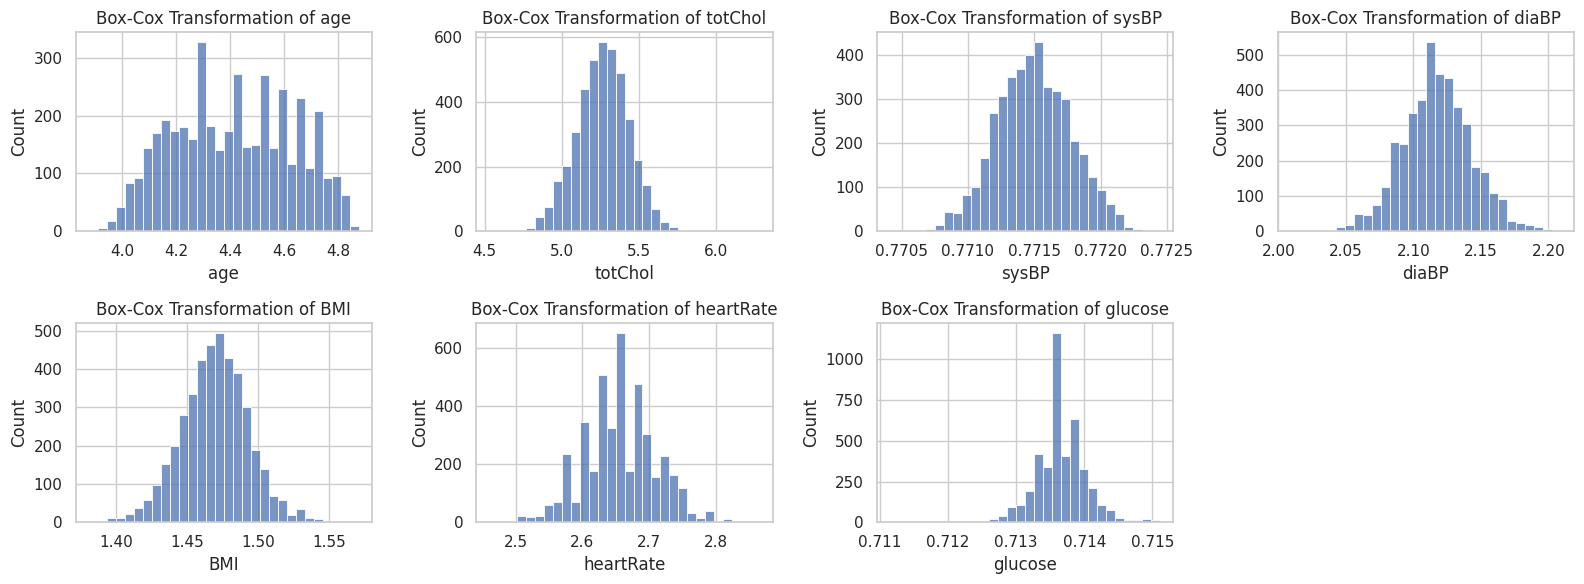

In [39]:
df_box_cox = df.copy()

boxcox_vars = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

# Verifique se os dados são positivos (Box-Cox requer valores positivos)
# Se houver valores <= 0, adicione um deslocamento mínimo
for col in boxcox_vars:
    if (df_box_cox[col] <= 0).any():
        print(f"Valores <= 0 encontrados na coluna {col}. Adicionando um deslocamento mínimo.")
        min_value = df_box_cox[col].min()
        print(f"Valor mín: {min_value:.2f}")
        df_box_cox[col] += abs(min_value) + 1  # Adiciona um deslocamento para tornar todos os valores positivos

boxcox_lambdas = {}
for col in boxcox_vars:
    df_box_cox[col], lambda_val = boxcox(df_box_cox[col])
    boxcox_lambdas[col] = lambda_val

print("Lambdas de transformação Box-Cox:")
for col, lambda_val in boxcox_lambdas.items():
    print(f"{col}: {lambda_val:.4f}")

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, col in enumerate(boxcox_vars):
    sns.histplot(data=df_box_cox, x=col, bins=30, ax=axes[i])
    axes[i].set_title(f'Box-Cox Transformation of {col}')

if num_plots < len(axes):
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])


plt.tight_layout()
plt.show()

In [40]:
formula = """
TenYearCHD ~ male + age + currentSmoker + cigsPerDay + BPMeds + education_2 +education_3 +education_4 +
prevalentStroke + prevalentHyp + diabetes + totChol + sysBP + diaBP + BMI +
heartRate +
male:currentSmoker + BPMeds:prevalentStroke + prevalentHyp:currentSmoker + prevalentStroke:currentSmoker + prevalentHyp:prevalentStroke
"""

y, X = patsy.dmatrices(formula, data=df_box_cox, return_type='dataframe')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variáveis selecionadas pelo método backward selection:")
print(selected_features)
print("\nResumo do modelo após backward selection:")
print(model.summary())
print("\nComparação de desempenho:")
print(f"Modelo backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))
auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variáveis selecionadas pelo método backward selection:
['Intercept', 'male', 'age', 'cigsPerDay', 'BPMeds', 'education_2', 'diabetes', 'totChol', 'sysBP', 'prevalentHyp:prevalentStroke']

Resumo do modelo após backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2958
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1207
Time:                        00:51:12   Log-Likelihood:                -1112.0
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 2.003e-60
                                   coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

Assim como a padronização, a transformação box cox não apresentou ganhos de ajuste ou de qualidade preditiva.
Além disso a transformação gerou uma distorção alta nos coeficienentes, prejudicando a interpretabilidade.

## Modelo aplicando winsorização


>"Winsorização é a transformação de estatísticas limitando valores extremos nos dados estatísticos para reduzir o efeito de valores atípicos possivelmente espúrios. Uma estratégia típica é definir todos os valores discrepantes para um percentil especificado dos dados; por exemplo, uma winsorização de 90% veria todos os dados abaixo do 5º percentil definidos como o 5º percentil e os dados acima do 95º percentil definidos como o 95º percentil."
[Wikipedia](https://en.wikipedia.org/wiki/Winsorizing)

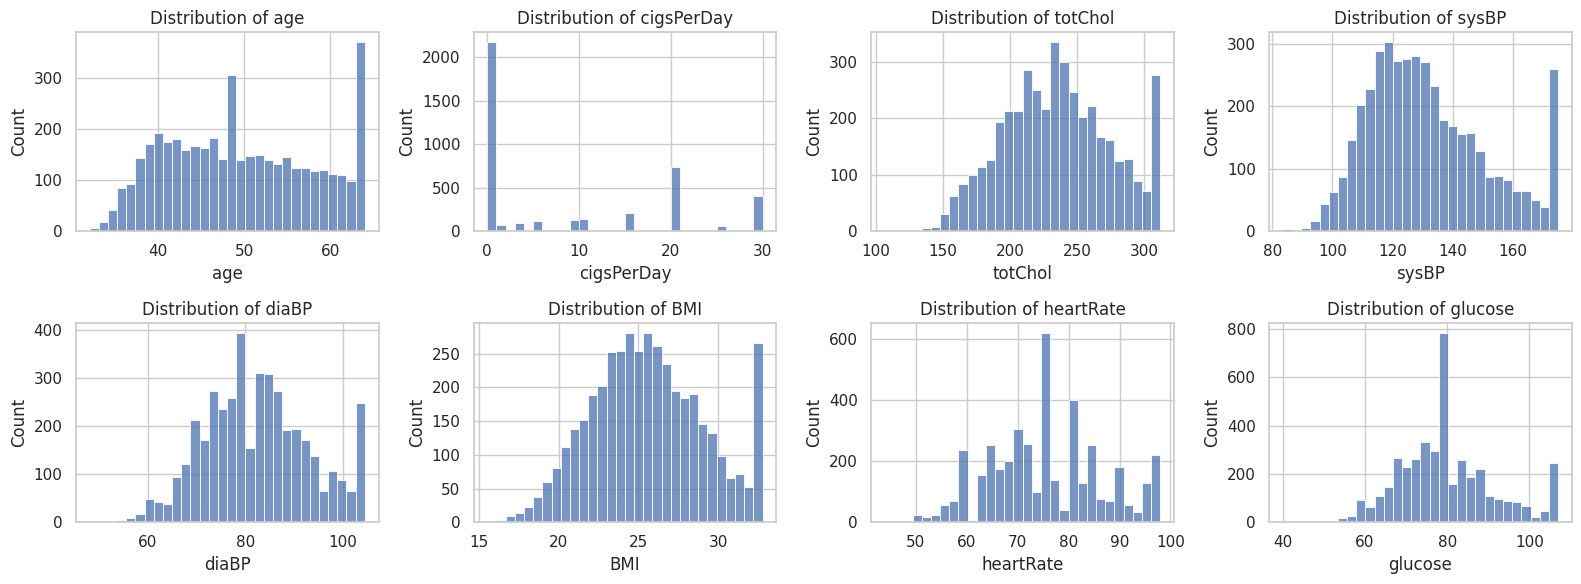

In [41]:
continuous_vars = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
def apply_winsorization(df, columns, limits=(0, 0.01)):
    for col in columns:
        df[col] = winsorize(df[col], limits=limits)
    return df

df_winsorized = df.copy()
df_winsorized = apply_winsorization(df_winsorized, continuous_vars, (0, 0.05)) # mantendo limite inferior como zero e trocando os máximos pelo percentil 95%

columns = continuous_vars
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(columns):
    sns.histplot(data=df_winsorized, x=col, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [42]:
formula = """
TenYearCHD ~ male + age + currentSmoker + cigsPerDay + BPMeds + education_2 +education_3 +education_4 +
prevalentStroke + prevalentHyp + diabetes + totChol + sysBP + diaBP + BMI +
heartRate +
male:currentSmoker + BPMeds:prevalentStroke + prevalentHyp:currentSmoker + prevalentStroke:currentSmoker + prevalentHyp:prevalentStroke
"""

y, X = patsy.dmatrices(formula, data=df_winsorized, return_type='dataframe')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variáveis selecionadas pelo método backward selection:")
print(selected_features)
print("\nResumo do modelo após backward selection:")
print(model.summary())
print("\nComparação de desempenho:")
print(f"Modelo backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))
auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variáveis selecionadas pelo método backward selection:
['Intercept', 'male', 'age', 'cigsPerDay', 'BPMeds', 'education_2', 'diabetes', 'sysBP', 'prevalentHyp:prevalentStroke']

Resumo do modelo após backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2968
Model:                          Logit   Df Residuals:                     2959
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1176
Time:                        00:51:14   Log-Likelihood:                -1115.9
converged:                       True   LL-Null:                       -1264.6
Covariance Type:            nonrobust   LLR p-value:                 1.410e-59
                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

## Modelo removendo valores Críticos

Dado que o objetivo é criar um modelo para analisar fatores de risco para o desenvolvimento da doença coronariana de forma ampla, é coerente filtrar casos atípicos de situações clínicas extremas, que não representam bem um caso típico de um paciente, como por exemplo, pressões arteriais próximas de uma crise hipertensa que devem ser tratadas imediatamente.

Com base em algumas referências médicas de institutos de acompanhamento de doenças e condições cardíacas foram definidos os seguintes cortes para algumas das variáveis:

| BLOOD PRESSURE CATEGORY                       | SYSTOLIC mm Hg (upper number) | and/or | DIASTOLIC mm Hg (lower number) |
|-----------------------------------------------|-------------------------------|--------|-------------------------------|
| NORMAL                                        | LESS THAN 120                 | and    | LESS THAN 80                  |
| ELEVATED                                      | 120 – 129                     | and    | LESS THAN 80                  |
| HIGH BLOOD PRESSURE (HYPERTENSION) STAGE 1    | 130 – 139                     | or     | 80 – 89                       |
| HIGH BLOOD PRESSURE (HYPERTENSION) STAGE 2    | 140 OR HIGHER                 | or     | 90 OR HIGHER                  |
| HYPERTENSIVE CRISIS (consult your doctor immediately) | HIGHER THAN 180              | and/or | HIGHER THAN 120               |


Referência [www.heart.org](https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings)

Results are given in milligrams per deciliter (mg/dL). Here are the ranges for total cholesterol in adults:

- *Normal*: Less than 200 mg/dL
- *Borderline high*: 200 to 239 mg/dL
- *High*: At or above 240 mg/dL

Referência: [www.hopkinsmedicine.org](https://www.hopkinsmedicine.org/health/treatment-tests-and-therapies/lipid-panel)



>**What is a good resting heart rate?**
There is no specific good resting heart rate. Well-trained athletes can have numbers in the 40s. But a heart rate that slow for the average person would be concerning and should prompt a call to your doctor's office, especially if you felt weak, lightheaded, or short of breath.

On the other end of the scale, a resting heart rate that is consistently above 90 beats per minute is also something your doctor should be aware of. Although it is still formally still normal, it could be a clue of something amiss, but not necessarily a serious problem.

Referência: [www.health.harvard.edu](https://www.health.harvard.edu/heart-health/what-your-heart-rate-is-telling-you)


In [43]:
limiares = {
    "sysBP": 180,
    "diaBP": 120,
    "totChol": 300,
    "heartRate": 120
}
percentis = {}
for variavel, limiar in limiares.items():
    percentis[variavel] = percentileofscore(df[variavel], limiar)
    print(f"O limiar {limiar} para {variavel} corresponde ao percentil {percentis[variavel]:.2f}%")

df_filtered = df[
    (df["sysBP"] <= limiares["sysBP"]) &
    (df["diaBP"] <= limiares["diaBP"]) &
    (df["totChol"] <= limiares["totChol"]) &
    (df["heartRate"] <= limiares["heartRate"])
].copy()

O limiar 180 para sysBP corresponde ao percentil 96.14%
O limiar 120 para diaBP corresponde ao percentil 99.17%
O limiar 300 para totChol corresponde ao percentil 92.16%
O limiar 120 para heartRate corresponde ao percentil 99.74%


In [44]:
print(f"Delta de tamanho: {round(((len(df_filtered) - len(df))*100/len(df)), 4)}%")

Delta de tamanho: -10.8019%


In [45]:
formula = """
TenYearCHD ~ male + age + education_2 +education_3 +education_4 + currentSmoker + cigsPerDay + BPMeds +
       prevalentStroke + prevalentHyp + diabetes + totChol + sysBP +
       diaBP + BMI + heartRate + glucose
"""
y, X = patsy.dmatrices(formula, data=df_filtered, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


significance_level = 0.05
model, selected_features = backward_selection(X_train, y_train, significance_level)

print("Variáveis selecionadas pelo método backward selection:")
print(selected_features)
print("\nResumo do modelo após backward selection:")
print(model.summary())
print("\nComparação de desempenho:")
print(f"Modelo backward - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

y_pred_prob_test  = model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")
y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))
auc = roc_auc_score(y_test, y_pred_prob_test)
print(f'ROC AUC: {auc:.4f}')

Variáveis selecionadas pelo método backward selection:
['Intercept', 'male', 'age', 'education_2', 'cigsPerDay', 'prevalentStroke', 'sysBP', 'glucose']

Resumo do modelo após backward selection:
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2647
Model:                          Logit   Df Residuals:                     2639
Method:                           MLE   Df Model:                            7
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                  0.1011
Time:                        00:51:14   Log-Likelihood:                -956.04
converged:                       True   LL-Null:                       -1063.6
Covariance Type:            nonrobust   LLR p-value:                 7.206e-43
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Inter

## Resumo dos modelos

| Modelo                      | Pseudo R-squ. | Log-Likelihood | AIC  | BIC  | Precision | Recall | Specificity | F1-Score | ROC AUC |
|-----------------------------|---------------|----------------|------|------|-----------|--------|-------------|----------|---------|
| Irrestrito                  | 0,1028        | -1103,7        | 2243 | 2351 | 24,6%     | 71,0%  | 61,1%       | 37,0%    | 70,1%   |
| Irrestrito balanceado       | 0,1815        | -1760          | 3556 | 3664 | 24,3%     | 71,5%  | 60,2%       | 36,0%    | 70,0%   |
| Modelo cru significativo    | 0,1246        | -1107          | 2232 | 2286 | 26,9%     | 62,7%  | 69,5%       | 38,0%    | 70,3%   |
| Modelo cru iteracoes        | 0,1214        | -1111          | 2240 | 2294 | 28,9%     | 57,5%  | 74,7%       | 38,0%    | 70,3%   |
| Modelo iteracoes padronizado| 0,1214        | -1111          | 2240 | 2294 | 28,9%     | 57,5%  | 74,7%       | 38,0%    | 70,3%   |
| Modelo iteracoes box-cox    | 0,1207        | -1112          | 2244 | 2304 | 28,7%     | 59,1%  | 73,8%       | 39,0%    | 70,1%   |
| Modelo winsorizado         | 0,1176        | -115,9           | 2250 | 2304 | 26,4%     | 65,3%  | 67,5%       | 38,0%    | 70,6%   |
| Modelo cru filtrado         | 0,1011        | -956           | 1928 | 1975 | 28,0%     | 67,5%  | 72,1%       | 40,0%    | 73,3%   |

Para o nosso contexto de aplicação, de um diagnóstico preventivo, o erro mais crítico é o do tipo II - um falso negativo, isto é, de uma pessoa que tem o risco de desenvolver a condição, mas que não ficaria ciente e não tomaria as devidas providências.

O erro tipo I de falsos positivos é menos preocupante, pois isso não implicaria necessariamente em um risco ao paciente, além de ser algo possível de se corrigir com continuidade de acompanhamento médico.

Logo para nossa análise, um bom nível de recall é mais impositivo para a decisão



| Reality          | Positive                   | Negative              |
|------------------|----------------------------|-----------------------|
| *Study Finding Positive* | *True Positive*<br>(Power)<br>(1-β) | False Positive<br>Type I Error (α) |
| *Study Finding Negative* | False Negative<br>Type II Error (β) | *True Negative*     |


Foram aplicadas diversas estratégias para melhorar o ajuste e interpretabilidade do modelo, incluindo seleção de variáveis, ponderação por classe, adição de interações e transformações como padronização e Box-Cox.
Tanto os modelos com padronização e transformações não trouxeram ganhos concretos e adicionaram um paço a mais para a interpretação dos resultados, sem apresentar melhoras de performance que justifiquem o tradeoff.

O modelo filtrado, que remove valores médicos críticos, apresentou os melhores resultados em termos de AIC, BIC e ROC AUC (0.7328), além de um equilíbrio melhor entre especificidade e recall. A remoção desses pontos reduziu provavelmente o impacto de outliers, tornando o modelo mais robusto. Diante disso, essa foi a abordagem escolhida para seguir como o modelo final.

# 4.Analisando o ajuste

Vamos manter o modelo sobre os dados filtrados e
as variáveis finais:

```
['Intercept', 'male', 'age', 'education_2', 'cigsPerDay', 'prevalentStroke', 'sysBP', 'glucose']
```
E avaliar o seu ajuste a diferentes funções de ligação.

1. O que são funções de link em GLMs?
  
  Nos Modelos Lineares Generalizados (GLMs), a função de link conecta a predição linear
  $$η=β0​+β1​X1​+⋯+βp​Xp​$$
  à média da variável resposta μ, através de uma transformação matemática.
 Ou seja:
  $$g(μ)=η$$
  onde g é a função de link.

2. Por que testar outras funções de link?
  Embora a função logit seja a escolha mais comum em modelos de regressão logística, outras funções podem ser mais adequadas dependendo das características dos seus dados:
  - Distribuição da variável resposta: O logit pode não capturar bem a relação entre as variáveis explicativas e a resposta.
  - Assimetrias nos dados: Se a relação entre as variáveis explicativas e a resposta não for bem representada pela função logit, outras funções podem melhorar o ajuste.

3. Funções de link que fazem sentido neste problema
  No contexto de uma variável binária (`TenYearCHD`), as funções de link mais comuns e relevantes são:
  - Logit (log-odds)
    - Fórmula: $g(μ)=ln⁡(\frac{μ}{ 1−μ})$
    - Interpretação: Relaciona a predição linear η ao logaritmo das chances (odds).
    - Por que usar: É a função padrão e amplamente aceita para dados binários.

  - Probit
    - Fórmula: $g(μ)=Φ^{-1}(μ)$, onde $Φ$ é a função de distribuição acumulada da normal padrão.
    - Interpretação: Assume que a probabilidade segue uma distribuição normal cumulativa.
    - Por que usar: Pode ser mais apropriada se a relação entre as variáveis for suavemente crescente e simétrica.

  - Complementary Log-Log (cloglog)
    - Fórmula: $g(μ)=ln⁡(−ln⁡(1−μ))$
    - Interpretação: É mais sensível a assimetrias, pois modela casos em que eventos extremos (probabilidades muito próximas de 0 ou 1) são mais prováveis.
    - Por que usar: Se há assimetrias fortes nos dados ou se os eventos de interesse (desenvolver DAC) são raros.


In [46]:
formula = """
TenYearCHD ~ male + age + education_2 + cigsPerDay + prevalentStroke + sysBP + glucose
"""

y, X = patsy.dmatrices(formula, data=df_filtered, return_type='dataframe')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

links = {
    'logit': Logit(),
    'probit': Probit(),
    'cloglog': CLogLog()
}

models = {}
for name, link in links.items():
  print(f"Ajustando modelo com função de link: {name}")
  model = sm.GLM(y_train, X_train, family=Binomial(link=link)).fit()
  models[name] = model
  print(model.summary())
  print(f"Modelo - AIC: {model.aic:.2f}, BIC: {model.bic_llf:.2f}") # Using bic_llf

Ajustando modelo com função de link: logit
                 Generalized Linear Model Regression Results                  
Dep. Variable:             TenYearCHD   No. Observations:                 2647
Model:                            GLM   Df Residuals:                     2639
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -956.04
Date:                Tue, 18 Feb 2025   Deviance:                       1912.1
Time:                        00:51:14   Pearson chi2:                 2.66e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.07805
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

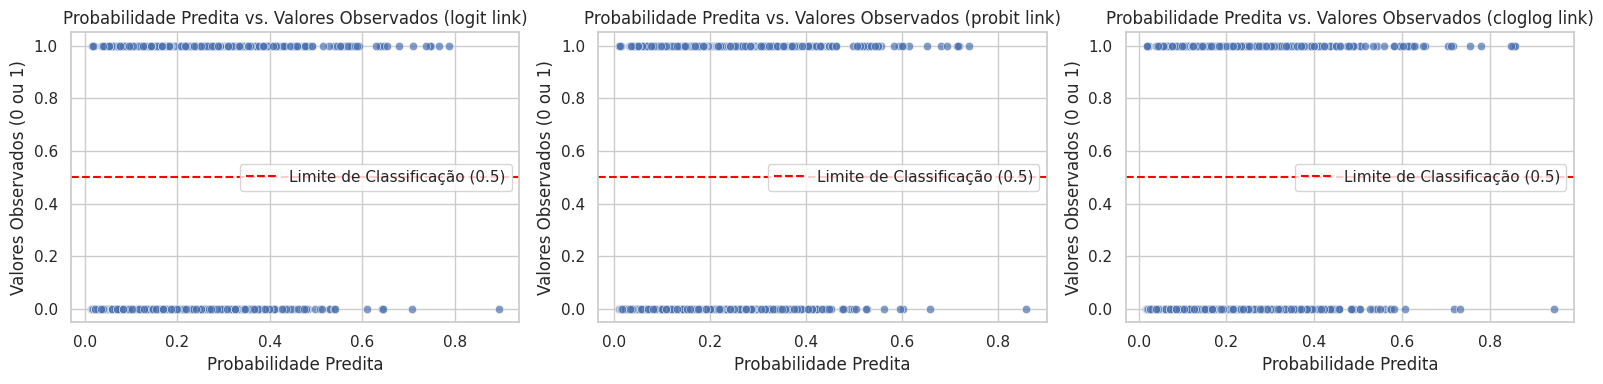

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, model) in enumerate(models.items()):
    prob_predicted = model.predict(X)

    sns.scatterplot(x=prob_predicted, y=y.iloc[:, 0], alpha=0.7, ax=axes[i])
    axes[i].axhline(0.5, color='red', linestyle='--', label="Limite de Classificação (0.5)")
    axes[i].set_title(f"Probabilidade Predita vs. Valores Observados ({name} link)")
    axes[i].set_xlabel("Probabilidade Predita")
    axes[i].set_ylabel("Valores Observados (0 ou 1)")
    axes[i].legend()

plt.tight_layout()
plt.show()

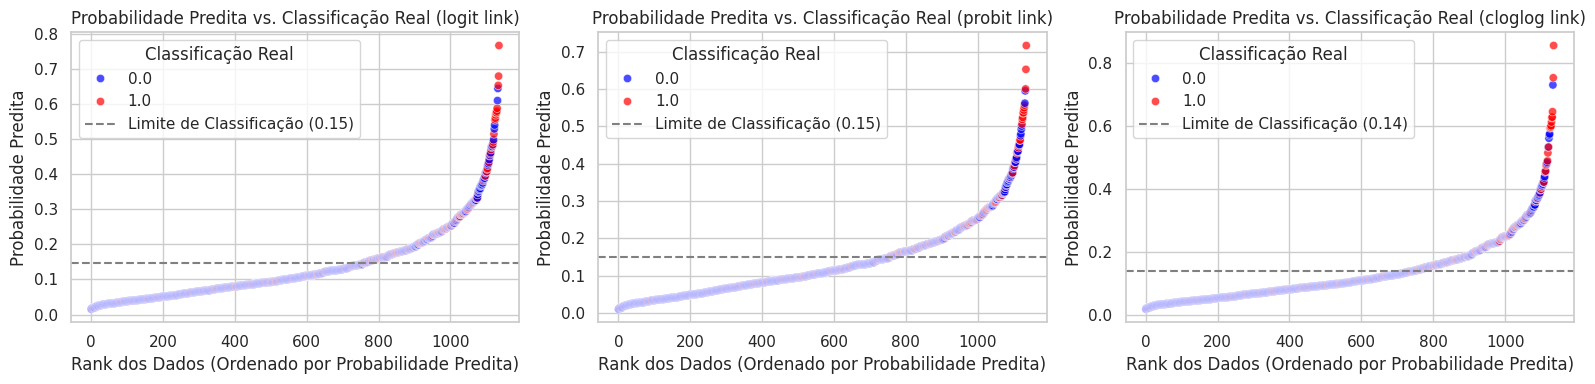

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, model) in enumerate(models.items()):
    y_pred_prob_test = model.predict(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
    youden_index = tpr - fpr
    optimal_threshold = thresholds[np.argmax(youden_index)]
    y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)


    df_plot = pd.DataFrame({'prob_predicted': y_pred_prob_test, 'TenYearCHD': y_test['TenYearCHD'].values})
    df_plot = df_plot.sort_values(by=['prob_predicted']).reset_index(drop=True)
    df_plot['rank'] = df_plot.index + 1

    sns.scatterplot(x='rank', y='prob_predicted', hue='TenYearCHD', data=df_plot, alpha=0.7, palette={0: 'blue', 1: 'red'},  ax=axes[i])
    axes[i].axhline(optimal_threshold, color='gray', linestyle='--', label=f"Limite de Classificação ({optimal_threshold:.2f})")
    axes[i].set_title(f"Probabilidade Predita vs. Classificação Real ({name} link)")
    axes[i].set_xlabel("Rank dos Dados (Ordenado por Probabilidade Predita)")
    axes[i].set_ylabel("Probabilidade Predita")
    axes[i].legend(title="Classificação Real", loc="upper left")

plt.tight_layout()
plt.show()

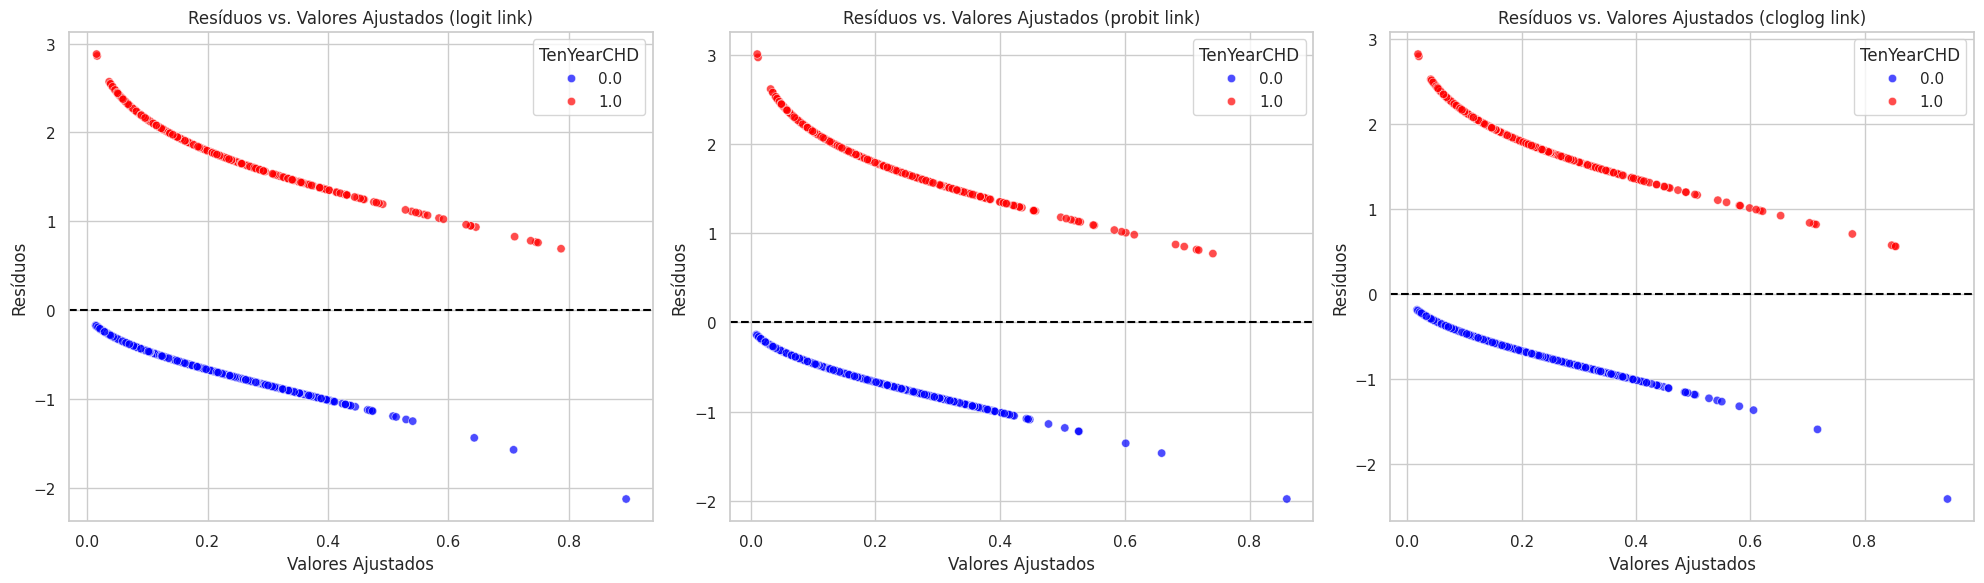

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model) in enumerate(models.items()):
    residuals = model.resid_deviance

    df_plot = pd.DataFrame({'fittedvalues': model.fittedvalues, 'residuals': residuals, 'TenYearCHD': y_train.iloc[:, 0]})

    sns.scatterplot(x='fittedvalues', y='residuals', hue='TenYearCHD', data=df_plot,
                    alpha=0.7, palette={0: 'blue', 1: 'red'}, ax=axes[i])
    axes[i].axhline(0, color='black', linestyle='--')
    axes[i].set_title(f"Resíduos vs. Valores Ajustados ({name} link)")
    axes[i].set_xlabel("Valores Ajustados")
    axes[i].set_ylabel("Resíduos")
    axes[i].legend(title="TenYearCHD")

plt.tight_layout()
plt.show()

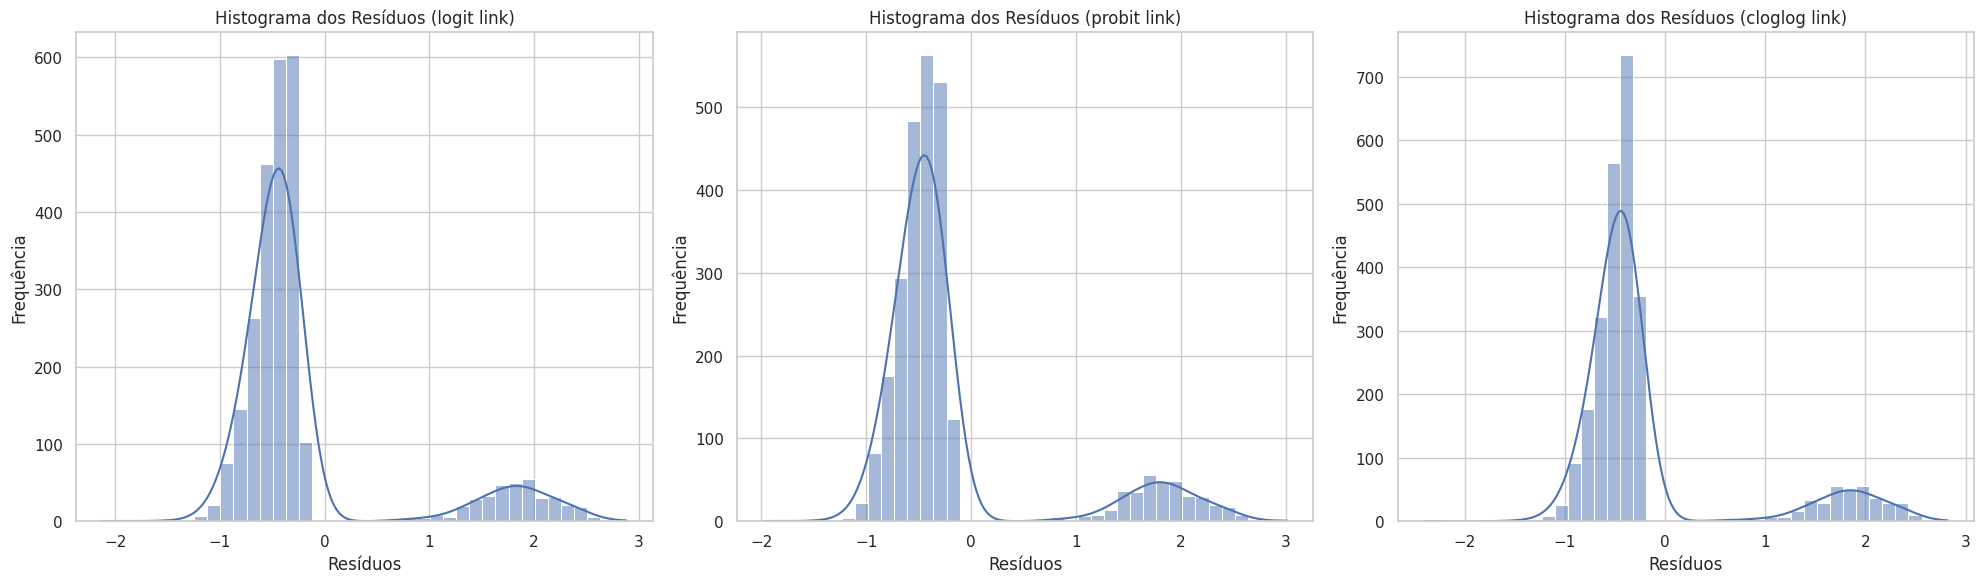

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # 1 row, 3 columns

for i, (name, model) in enumerate(models.items()):
    residuals = model.resid_deviance

    sns.histplot(residuals, kde=True, bins=40, ax=axes[i])
    axes[i].set_title(f"Histograma dos Resíduos ({name} link)")
    axes[i].set_xlabel("Resíduos")
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

Para um bom ajuste, a distribuição dos resíduos deve ser aproximadamente simétrica e centrada em torno de 0.

O comportamento bimodal (dois picos) indica que os resíduos não seguem uma distribuição normal esperada.
Isso pode significar que há grupos distintos nos dados que o modelo não conseguiu capturar adequadamente.

Potenciais problemas:
- Heterocedasticidade: A variância dos resíduos pode não ser constante, indicando que o modelo está ajustando melhor para alguns intervalos de valores e pior para outros.


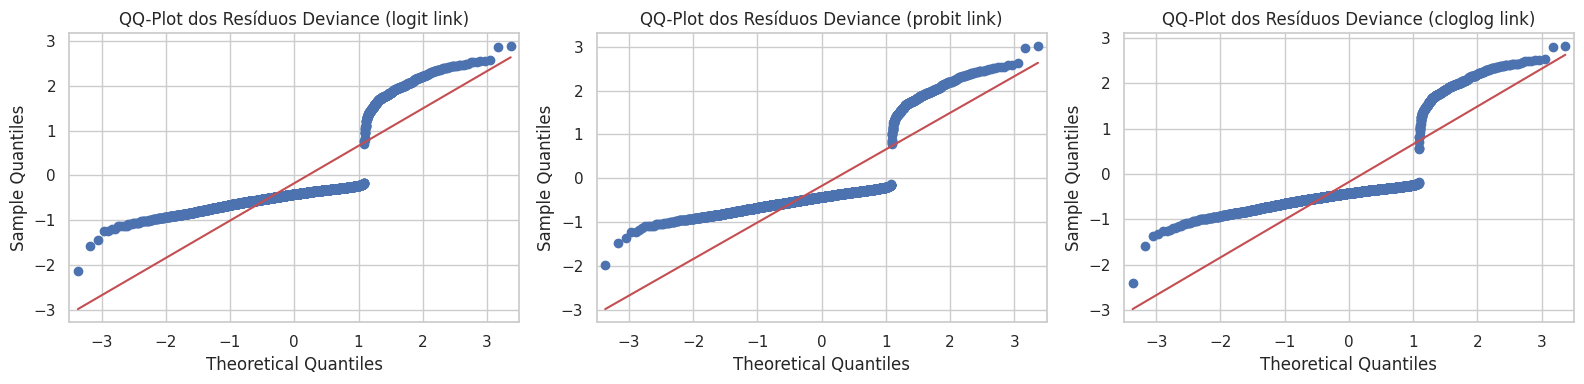

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 1 row, 3 columns

for i, (name, model) in enumerate(models.items()):
    residuals = model.resid_deviance

    sm.qqplot(residuals, line='s', ax=axes[i])
    axes[i].set_title(f"QQ-Plot dos Resíduos Deviance ({name} link)")

plt.tight_layout()
plt.show()

O QQ-plot (Quantile-Quantile Plot) é uma ferramenta gráfica usada para comparar a distribuição dos resíduos (ou qualquer conjunto de dados) com uma distribuição teórica esperada, geralmente a distribuição normal.
- Eixo X (Theoretical Quantiles): Representa os quantis da distribuição teórica (ex.: normal).
- Eixo Y (Sample Quantiles): Representa os quantis observados nos dados.

Se os dados seguem a distribuição teórica esperada:
Os pontos do QQ-plot devem formar uma linha reta próxima à linha vermelha (diagonal).

Neste Caso:
1. Curvatura nos extremos:
  Os gráficos apresentam curvaturas nas caudas, com os pontos afastando-se significativamente da linha vermelha. Isso sugere que os resíduos não seguem uma distribuição normal, especialmente nos extremos.
2. Segmentação no centro:
  Existe uma espécie de separação ou "patamar" no centro do gráfico. Isso pode indicar grupos de dados distintos ou que a relação modelada não captura bem algumas características dos dados.
3. Impacto prático:
  O padrão observado pode sugerir que o modelo está violando a suposição de normalidade dos resíduos.
  Outra possibilidade é que a variabilidade dos dados (ou a dispersão dos resíduos) não esteja sendo explicada completamente pelo modelo atual.


# 5.Interpretando o Modelo

---

Apesar da modesta qualidade do ajuste do modelo - que vimos pelas análises anteriores demonstrar se ser subótimo. Gostaria de explorar a interpretabilidade direta que o modelo logístico fornece por meio dos coeficientes como mudanças nos odds ratio.


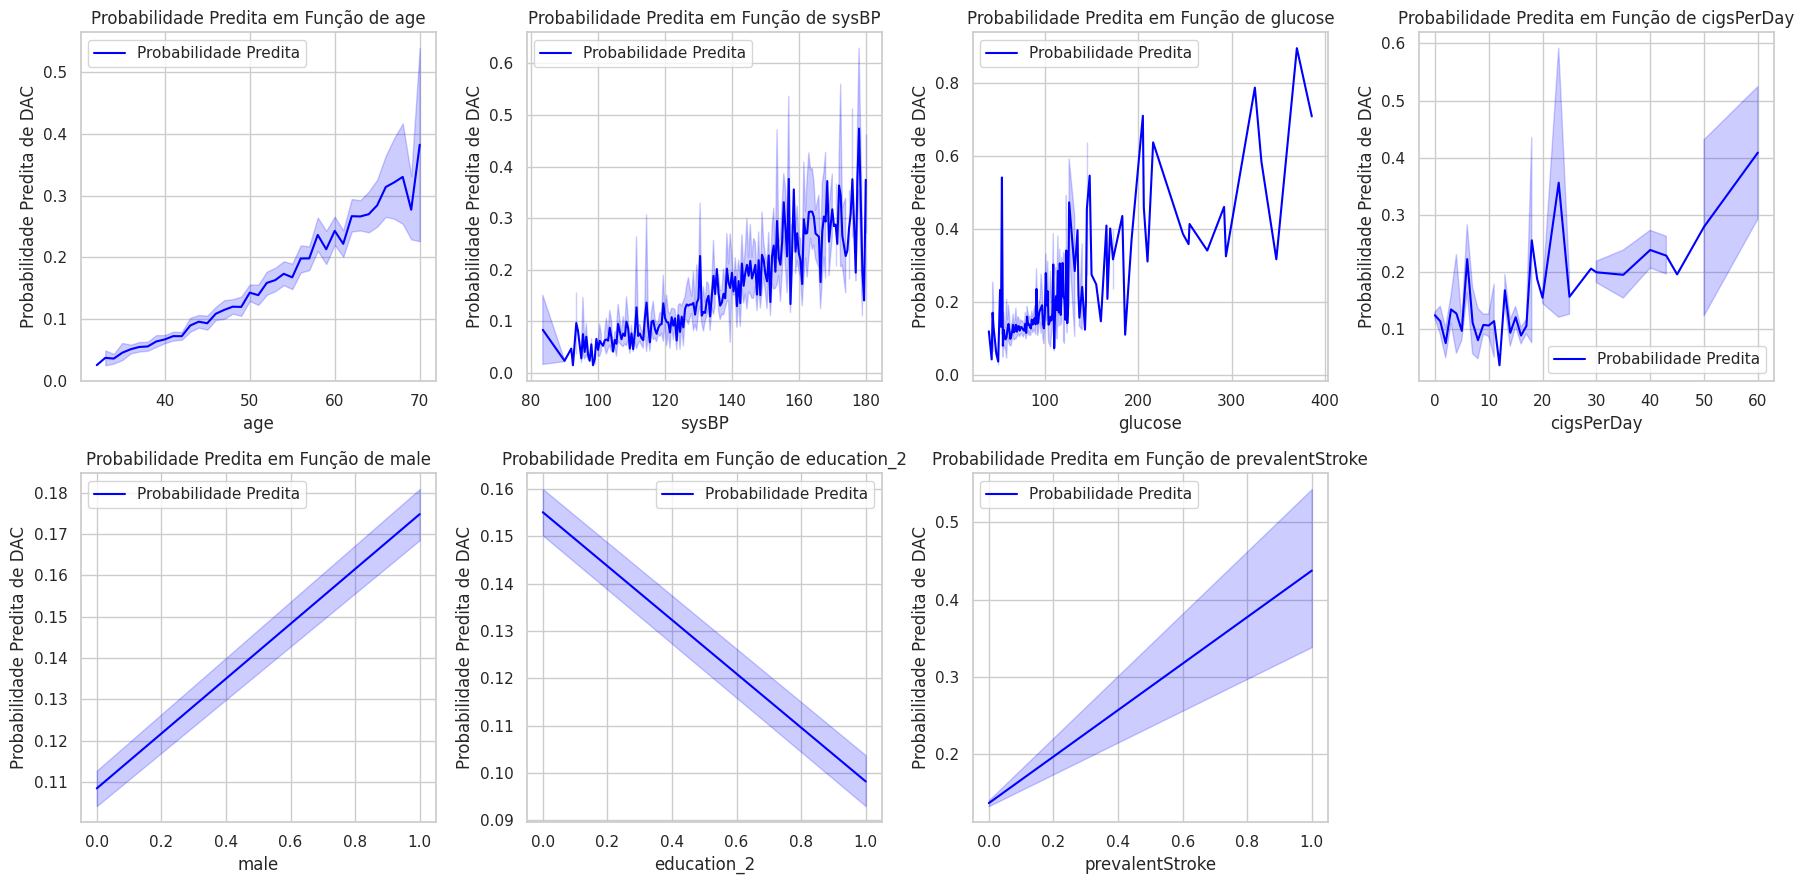

In [52]:
predictor_vars = ['age', 'sysBP', 'glucose', 'cigsPerDay', 'male', 'education_2',  'prevalentStroke']
prob_predicted = models['logit'].predict(X_train)

num_rows = 2
num_cols = 4
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 9))

for i, var in enumerate(predictor_vars):
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col]

    sns.lineplot(x=X_train[var], y=prob_predicted, label="Probabilidade Predita", color='blue', ax=ax)
    ax.set_title(f"Probabilidade Predita em Função de {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Probabilidade Predita de DAC")
    ax.legend()

for i in range(len(predictor_vars), num_rows * num_cols):
    fig.delaxes(axes[i // num_cols, i % num_cols])

plt.tight_layout()
plt.show()

1. Fatores de risco bem estabelecidos:

  Variáveis como age e sysBP demonstram um aumento progressivo e bem definido da probabilidade de DAC, reforçando achados já conhecidos da literatura médica sobre os impactos do envelhecimento e da hipertensão na saúde cardiovascular.

2. Efeito do histórico de AVC:

  A variável prevalentStroke mostra um efeito significativo, com indivíduos que já tiveram AVC apresentando uma maior probabilidade predita de DAC. Isso sugere que condições cardiovasculares prévias são um forte preditor da doença.

3. Comportamento de glicose e tabagismo:

  * O aumento dos níveis de glicose parece estar associado a uma maior probabilidade de DAC, mas a variabilidade nos dados indica que pode haver um comportamento mais complexo, talvez mediado por fatores como diabetes e estilo de vida. Note que nessa faixa de valores o volume de dados é menor, o que também aumenta a incerteza da medida.
  * O consumo de cigarros (cigsPerDay) também está correlacionado a um risco maior, especialmente para valores mais elevados, mas com maior incerteza estatística devido ao menor volume de amostras.

4. Papel da educação e do gênero:

  * Indivíduos com nível educacional education_2 apresentam uma menor probabilidade predita de DAC, sugerindo que fatores socioeconômicos podem desempenhar um papel protetor.
  * Homens tendem a ter um risco um pouco maior de DAC, o que pode estar relacionado a fatores hormonais, comportamentais ou históricos de exposição a hábitos de risco.


**Chances x Probabilidades**

As chances a favor de meu time ganhar o jogo são de 1 para 4

Nesse exemplo, teríamos um total de 5 jogos, um dos quais meu time ganharia e quatro dos quais meu time perderia.

As chances não são probabilidades, são uma razão entre algo que acontece (ou seja, meu time ganha) e algo que não acontece (ou seja, meu time não ganha)

Probabilidade é a razão entre algo que pode acontecer (ou seja, meu time ganha) e tudo o que seria possível de acontecer (ou seja, meu time ganha e perde).

As chances podem ser calculadas por meio da razão de probabilidades:

$$ \frac{\text{probabilidade de ganhar}}{\text{probabilidade de perder}} \\
=
\frac{\text{probabilidade de ganhar}}{\text{1 - probabilidade de ganhar}}\\
= \frac{p}{(1-p)}
$$

O comportamento das chances é assimétrico, quando dizemos que as chances de um evento são baixas (exempo do jogo de 1 para 4), o seu valor será um numéro no intervalo $[0,1)$.

Já quando as chances são positivas (2 para 1) as chances vão assumir um valor entre  1 e infinito.

Para corrigir a assimetria e facilitar a análise é comum aplicar o logaritmo das chances "*Log Odds Ratio*", também conhecido como função *logit*. O logit pode crescer até o infinito positivo a medida que as chances estarem a favor do evento observado e, por outro lado, baixar até o infinito negativo no caso das chances estarem contra o evento.

In [53]:
coefficients = models['logit'].params[1:]
selected_features = models['logit'].model.exog_names[1:]
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coeficiente': coefficients,
    'Odds Ratio': np.exp(coefficients)
})

coef_df = coef_df.sort_values(by='Coeficiente', ascending=False)
print(coef_df)

                         Feature  Coeficiente  Odds Ratio
prevalentStroke  prevalentStroke     1.207538    3.345239
male                        male     0.373721    1.453132
age                          age     0.059137    1.060921
cigsPerDay            cigsPerDay     0.025515    1.025843
sysBP                      sysBP     0.019477    1.019668
glucose                  glucose     0.008224    1.008258
education_2          education_2    -0.312967    0.731274


**1. Odds Ratio (OR): O que significa?**

- O OR mede o quanto o aumento de uma unidade em uma variável aumenta (ou reduz) a chance de um evento ocorrer.
- OR > 1: Aumenta a chance do evento (fator de risco).
- OR < 1: Reduz a chance do evento (fator protetor).
- OR = 1: Não há impacto na probabilidade do evento.
O coeficiente no modelo é o logaritmo natural do OR, ou seja:

$$OR = e ^{\text{Coeficiente}}$$

1. Fatores de maior impacto:

  * Histórico de AVC (prevalentStroke): OR = 3.35

    → Indivíduos que já tiveram um AVC têm mais de 3 vezes a chance de desenvolver DAC em comparação com aqueles que não tiveram.
    
    
  * Sexo masculino (male): OR = 1.45
    
    → Homens têm um aumento de 45% na chance de DAC em relação às mulheres.
    
2. Impacto do envelhecimento e fatores de risco conhecidos:

  * Idade (age): OR = 1.06

    → Para cada ano adicional de idade, a chance de DAC aumenta 6%.

    → Pequeno efeito unitário, mas com impacto acumulativo significativo ao longo do tempo.

  * Pressão arterial sistólica (sysBP): OR = 1.02
    
    → Cada ponto a mais na pressão arterial sistólica aumenta a chance de DAC em 2%.

  * Glicose (glucose): OR = 1.008
    
    → Pequeno efeito unitário (0.8% por ponto de glicose), mas relevante, especialmente para valores mais elevados.

3. Fatores comportamentais:

  * Cigarros por dia (cigsPerDay): OR = 1.025

    → Cada cigarro adicional aumenta a chance de DAC em 2.5%.

    → Pequeno efeito unitário, mas fumantes pesados acumulam um grande risco. Um maço de cigarros tem em média 20 unidades, o que indicaria aumento de 50% por masso/dia
4. Fatores protetivos:

  * Nível educacional (education_2): OR = 0.73
    
    → Indivíduos com esse nível educacional têm 27% menos chance de DAC.
    
    → Possível efeito de maior conhecimento sobre saúde e acesso a melhores cuidados médicos.


# 6.Sugestões de Leitura
---


* [SMOTE: Synthetic Minority Over-sampling Technique](https://arxiv.org/pdf/1106.1813)
* [Google ML Crash Course](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall)
* [An Introduction to Statistical Learning](https://www.statlearning.com/)
* [R-Project](https://cran.r-project.org/web/packages/sjPlot/vignettes/plot_interactions.html)
* [LOESS plot](https://en.wikipedia.org/wiki/Local_regression)
* [Youden's J statistic](https://en.wikipedia.org/wiki/Youden%27s_J_statistic)
* [Odds and Log(Odds), Clearly Explained!!!](https://youtu.be/ARfXDSkQf1Y)
* [Over Samplig Practical Guide Sklearn](https://imbalanced-learn.org/stable/over_sampling.html#)

# Extra: Evaluating SMOTE oversampling technique
---

>Synthetic Minority Oversampling Technique (SMOTE) is a statistical technique for increasing the number of cases in your dataset in a balanced way. The component works by generating new instances from existing minority cases that you supply as input. This implementation of SMOTE does not change the number of majority cases.

>The new instances are not just copies of existing minority cases. Instead, the algorithm takes samples of the feature space for each target class and its nearest neighbors. The algorithm then generates new examples that combine features of the target case with features of its neighbors. This approach increases the features available to each class and makes the samples more general.

[learn.microsoft](https://learn.microsoft.com/en-us/azure/machine-learning/component-reference/smote?view=azureml-api-2)

Iremos seguir nesse caso com o pacote de Sklearn  para implementação e seleção de variáveis.
Iremos aplicar o método SMOTE para melhorar o balanceamento das classes nos dados e avaliar possíveis ganhos de capacidade preditiva

Separar os dados primeiro e tratar treino e teste e depois aplicar as transformações somente no conjunto de treino. O conjunto de teste é transformado usando os parâmetros calculados no treino.

**Vantagens**:
- Evita fuga de informações: Parâmetros como média e desvio padrão são calculados apenas no conjunto de treino, simulando o cenário do mundo real onde os dados de teste são desconhecidos.
- Avaliação realista: A performance do modelo reflete sua capacidade de generalização.


In [54]:
df = pd.read_csv(path+'/framingham.csv')
df = create_dummies(df, categorical_vars_with_dummies=['education'])
df = df.rename(columns={
    'education_2.0': 'education_2',
    'education_3.0': 'education_3',
    'education_4.0': 'education_4'
})

X = df.drop(columns=["TenYearCHD"])
y = df["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


numeric_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
categorical_cols = ['BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'currentSmoker', 'male']


numeric_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = numeric_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = numeric_imputer.transform(X_test[numeric_cols])

categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = categorical_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = categorical_imputer.transform(X_test[categorical_cols])

smote = SMOTE(sampling_strategy="auto", random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Ajudou na convergência do algoritmo
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

In [55]:
y_train_resampled.value_counts(normalize=True)

,proportion
TenYearCHD,
0,0.5
1,0.5


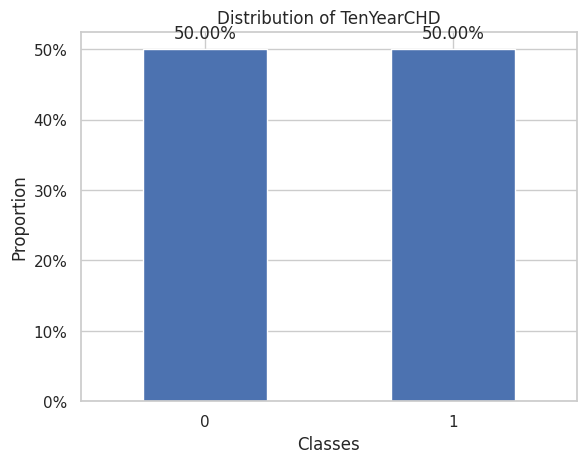

In [56]:
class_proportions = y_train_resampled.value_counts(normalize=True)
ax = class_proportions.plot(kind='bar', rot=0)
for p in ax.patches:
  height = p.get_height()
  ax.annotate(f'{height:.2%}', (p.get_x() + p.get_width() / 2., height),
              ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

ax.set_title('Distribution of TenYearCHD')
ax.set_xlabel('Classes')
ax.set_ylabel('Proportion')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

In [57]:
model = LogisticRegression(random_state=42, penalty='l1', solver='saga')
model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(penalty='l1', random_state=42, solver='saga')

In [58]:
y_pred_prob_test  = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)


tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

Optimal threshold: 0.5088
Precision: 0.2500
Recall: 0.5389
Specificity: 0.7108
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1079
           1       0.25      0.54      0.34       193

    accuracy                           0.68      1272
   macro avg       0.57      0.62      0.57      1272
weighted avg       0.80      0.68      0.72      1272



Sem ganhos significativos em relação ao modelo irrestrito:



```
              precision    recall  f1-score   support

         0.0       0.92      0.61      0.73      1079
         1.0       0.25      0.71      0.37       193

    accuracy                           0.63      1272
   macro avg       0.58      0.66      0.55      1272
weighted avg       0.82      0.63      0.68      1272

```
Houve apenas uma redução do recall


In [59]:
coefficients = model.coef_
feature_names = X_train.columns
for feature, coef in zip(feature_names, coefficients[0]): # coefficients[0] to access the first row
    print(f"{feature}: {coef:.4f}")

male: 0.1669
age: 0.5473
currentSmoker: -0.0242
cigsPerDay: 0.3209
BPMeds: 0.1405
prevalentStroke: 0.1316
prevalentHyp: 0.1277
diabetes: -0.0577
totChol: 0.1632
sysBP: 0.0899
diaBP: 0.1412
BMI: -0.0395
heartRate: -0.0824
glucose: 0.2335
education_2: -0.7403
education_3: -0.5763
education_4: -0.4440


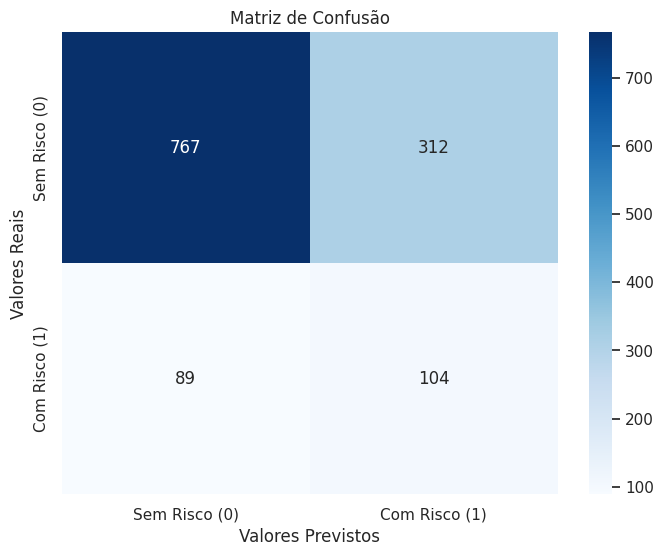

In [60]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sem Risco (0)", "Com Risco (1)"],
            yticklabels=["Sem Risco (0)", "Com Risco (1)"])
plt.xlabel("Valores Previstos")
plt.ylabel("Valores Reais")
plt.title("Matriz de Confusão")
plt.show()

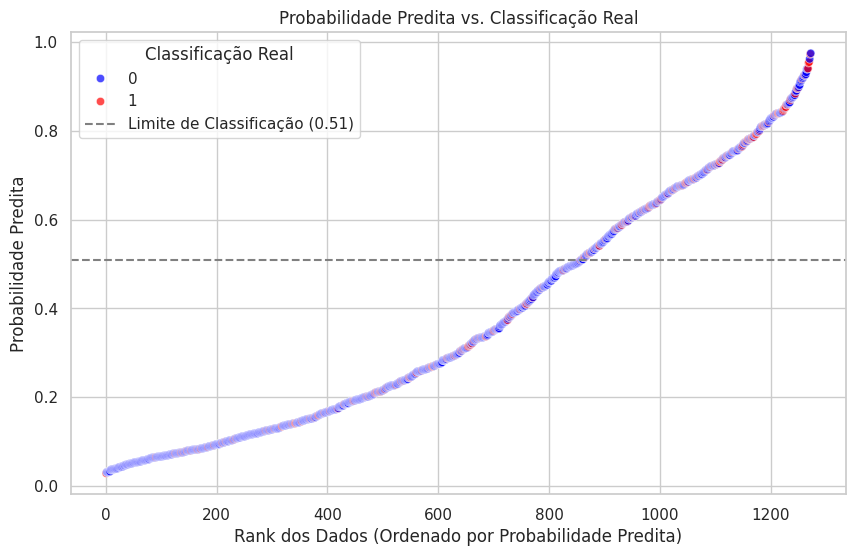

In [61]:
df_plot = pd.DataFrame({'prob_predicted': y_pred_prob_test, 'TenYearCHD': y_test.values})

df_plot = df_plot.sort_values(by=['prob_predicted']).reset_index(drop=True)
df_plot['rank'] = df_plot.index + 1

plt.figure(figsize=(10, 6))
sns.scatterplot(x='rank', y='prob_predicted', hue='TenYearCHD', data=df_plot, alpha=0.7, palette={0: 'blue', 1: 'red'})

plt.axhline(optimal_threshold, color='gray', linestyle='--', label=f"Limite de Classificação ({optimal_threshold:.2f})")  # Linha de corte
plt.title("Probabilidade Predita vs. Classificação Real")
plt.xlabel("Rank dos Dados (Ordenado por Probabilidade Predita)")
plt.ylabel("Probabilidade Predita")
plt.legend(title="Classificação Real", loc="upper left")
plt.show()

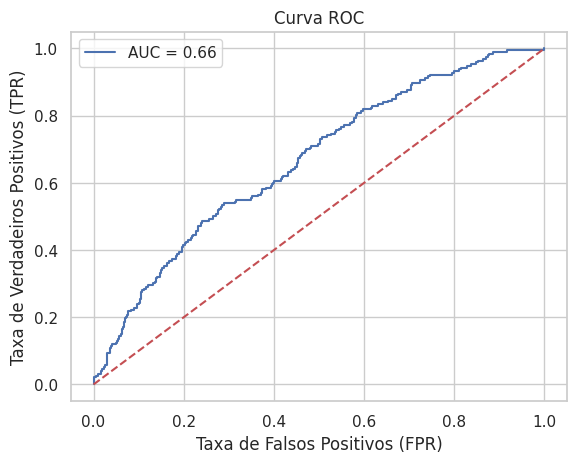

In [62]:
# Variáveis reais e predições
y_true = y_test.values  # Substitua pelo nome da sua variável dependente

# Calculando a curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob_test)
auc = roc_auc_score(y_true, y_pred_prob_test)

# Plot
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'r--')  # Linha de referência
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.show()


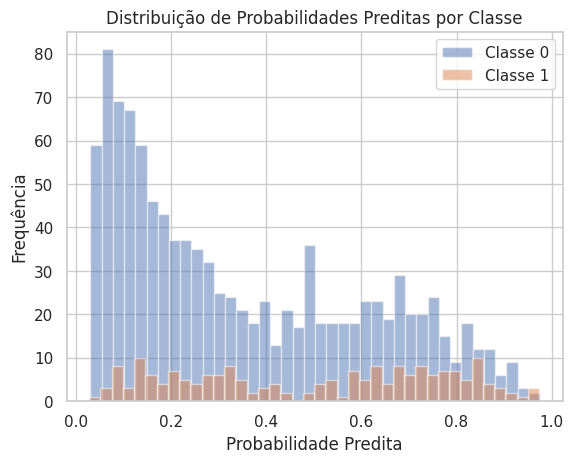

In [63]:
plt.hist(y_pred_prob_test[y_true == 0], bins=40, alpha=0.5, label="Classe 0")
plt.hist(y_pred_prob_test[y_true == 1], bins=40, alpha=0.5, label="Classe 1")
plt.xlabel("Probabilidade Predita")
plt.ylabel("Frequência")
plt.title("Distribuição de Probabilidades Preditas por Classe")
plt.legend()
plt.show()


## Validação cruzada
---
Avaliar a estabilidade do modelo com diferentes conjuntos como teste e treino

In [64]:
# transformando a variável y-train em um array-like object
y_train_ravel = y_train_resampled.values.ravel()

# Validação cruzada (5 folds)
cv_scores = cross_val_score(model, X_train_resampled, y_train_ravel, cv=5, scoring='roc_auc')

print(f"AUC por fold: {cv_scores}")
print(f"AUC média: {cv_scores.mean():.3f}")
print(f"Desvio padrão da AUC: {cv_scores.std():.3f}")

AUC por fold: [0.68432658 0.82789769 0.85565575 0.8156892  0.84268544]
AUC média: 0.805
Desvio padrão da AUC: 0.062


## Usando o modelo filtrado com as varíaveis significativas

In [65]:
X = df_filtered[['male', 'age', 'education_2', 'cigsPerDay', 'prevalentStroke', 'sysBP', 'glucose']]
y = df_filtered["TenYearCHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

smote = SMOTE(sampling_strategy="auto", random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Ajudou na convergência do algoritmo
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

In [66]:
model = LogisticRegression(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(random_state=42)

In [67]:
y_pred_prob_test  = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]
print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred_test = np.where(y_pred_prob_test >= optimal_threshold, 1, 0)


tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y_test, y_pred_test))

Optimal threshold: 0.5179
Precision: 0.2189
Recall: 0.5605
Specificity: 0.6789
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       978
           1       0.22      0.56      0.31       157

    accuracy                           0.66      1135
   macro avg       0.56      0.62      0.55      1135
weighted avg       0.81      0.66      0.71      1135



In [68]:
# transformando a variável y-train em um array-like object
y_train_ravel = y_train_resampled.values.ravel()

# Validação cruzada (5 folds)
cv_scores = cross_val_score(model, X_train_resampled, y_train_ravel, cv=5, scoring='roc_auc')

print(f"AUC por fold: {cv_scores}")
print(f"AUC média: {cv_scores.mean():.3f}")
print(f"Desvio padrão da AUC: {cv_scores.std():.3f}")

AUC por fold: [0.69014166 0.77350378 0.75527085 0.77164608 0.76990516]
AUC média: 0.752
Desvio padrão da AUC: 0.032
